In [1]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

#load dataset
file_path = '/content/drive/MyDrive/fire_pollution_dataset_daily_cleaned.csv'
lag_dataset = pd.read_csv(file_path)

#ensure proper datetime + sorting
#lag_dataset['date'] = pd.to_datetime(lag_dataset['date'])
#lag_dataset = lag_dataset.sort_values('date').reset_index(drop=True)

# create lag features
# min_lag = 0
# max_lag = 5

# for lag in range(min_lag, max_lag + 1):
#     lag_dataset[f'fire_lag_{lag}'] = lag_dataset['fire_count'].shift(lag)
#     lag_dataset[f'frp_lag_{lag}'] = lag_dataset['total_frp'].shift(lag)
#     lag_dataset[f'fire_anomaly_lag_{lag}'] = lag_dataset['fire_anomaly'].shift(lag)
#     lag_dataset[f'frp_anomaly_lag_{lag}'] = lag_dataset['frp_anomaly'].shift(lag)

# lag_dataset = lag_dataset.dropna().reset_index(drop=True)

# lag_features = [col for col in lag_dataset.columns if 'lag_' in col]
# print("Lag Features:", lag_features)

# save_path = '/content/drive/MyDrive/fire_pollution_dataset_lag_cleaned.csv'
# lag_dataset.to_csv(save_path, index=False)

# print("Saved to:", save_path)

Mounted at /content/drive


# Exploratory Data Analysis

# Fire Activity Time Series

          fire_count                                 total_frp               \
                 sum       mean         max  min           sum         mean   
year_x                                                                        
2018    26189.592157  15.451087  299.000000  0.0  3.898859e+06  2300.212040   
2019    20600.333333  12.004856  287.000000  0.0  3.987458e+06  2323.693277   
2020    31700.690196  18.495152  232.000000  0.0  5.519449e+06  3220.215412   
2021    46495.560784  27.111114  441.482353  0.0  8.895433e+06  5186.841255   
2022    14250.215686   9.217475   98.000000  0.0  3.775018e+06  2441.796672   
2023     3895.890196   2.270332   29.000000  0.0  6.795069e+05   395.983055   

                              burned_area                             \
                  max  min            sum         mean           max   
year_x                                                                 
2018     35593.000000  0.0  280277.238239  4917.144531  14519.025619   


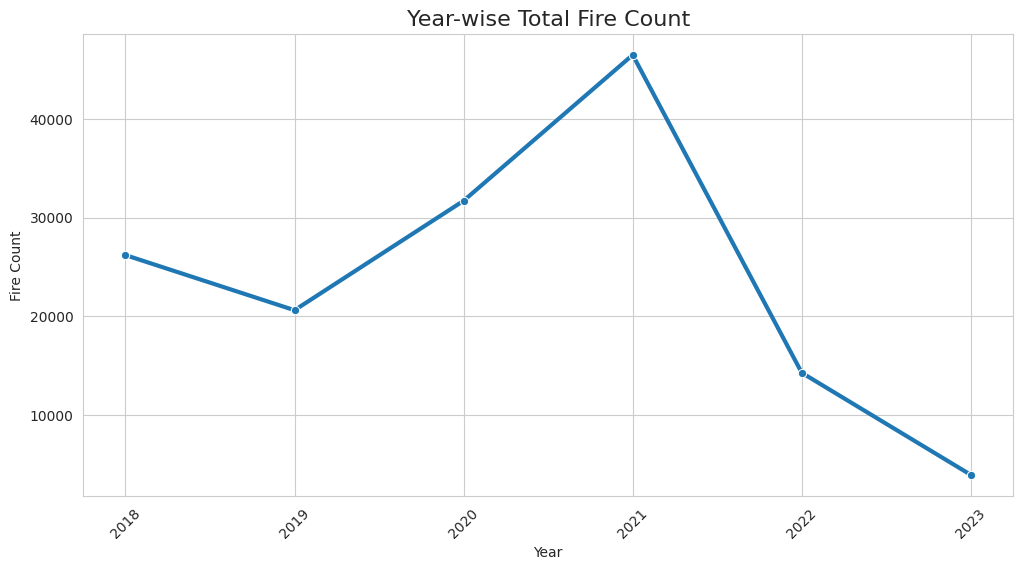

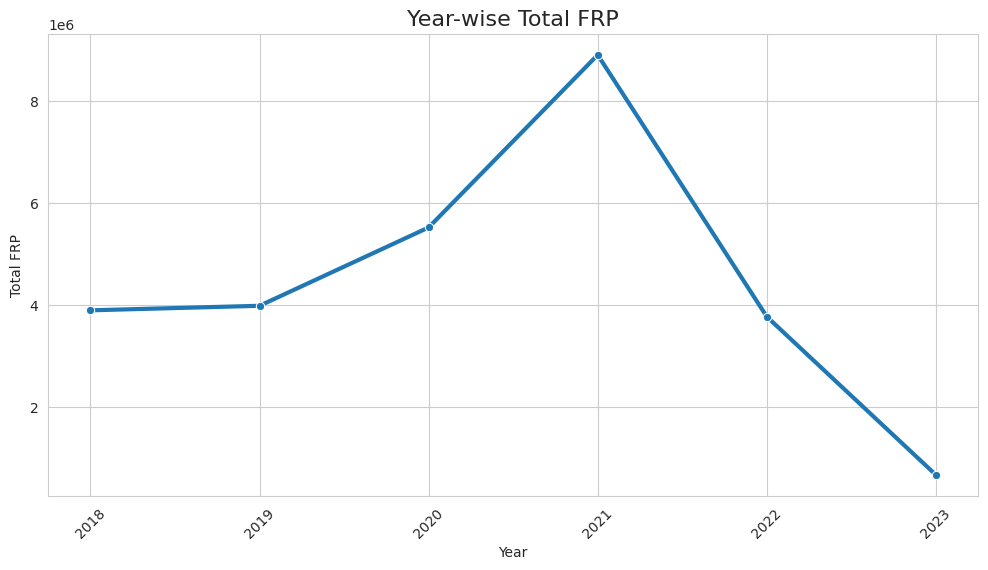

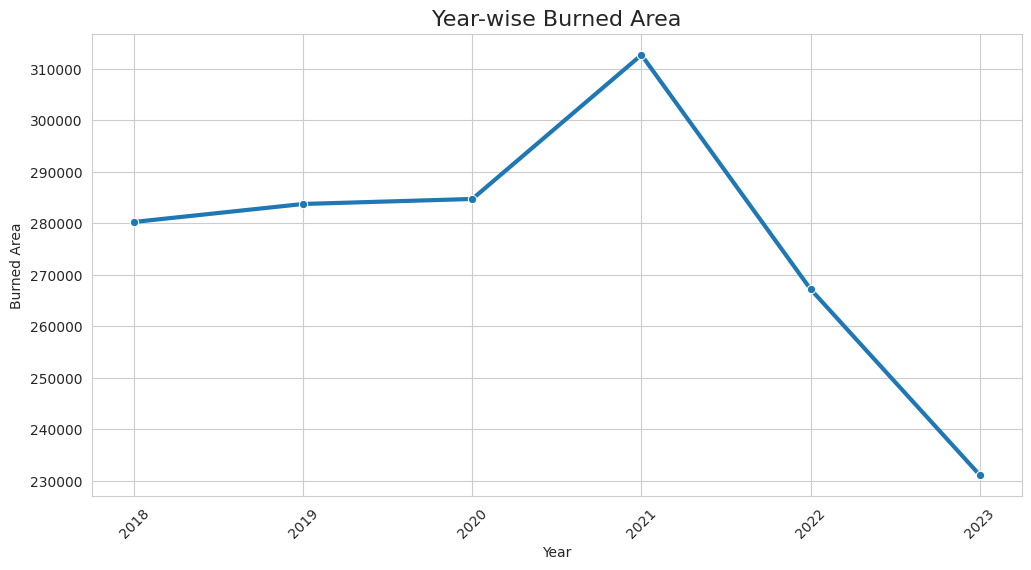

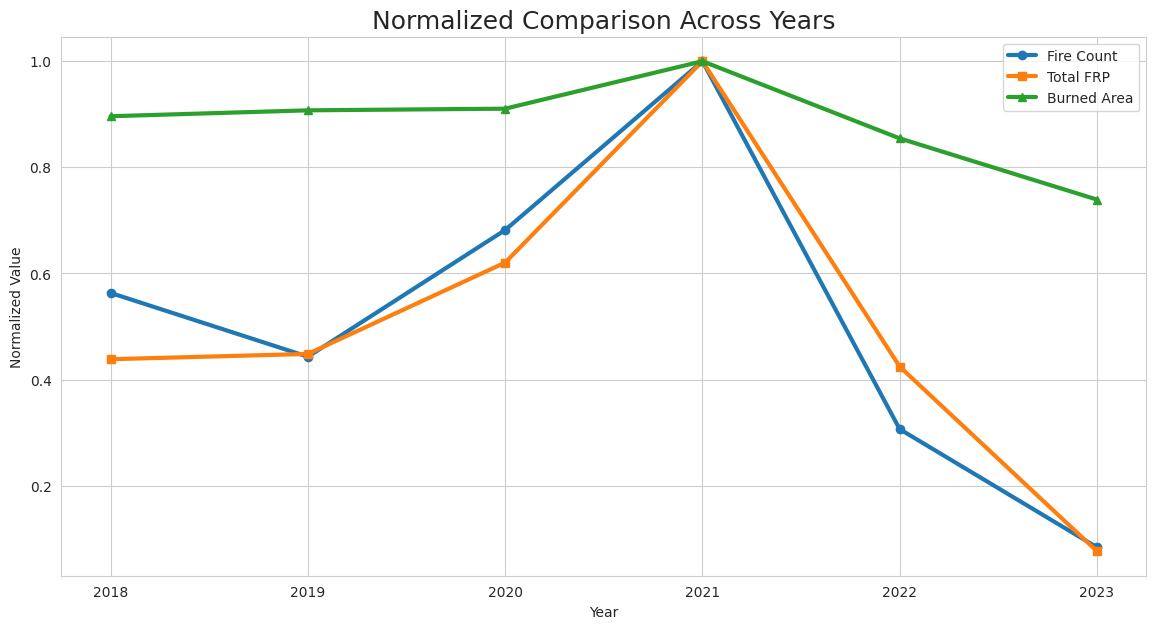

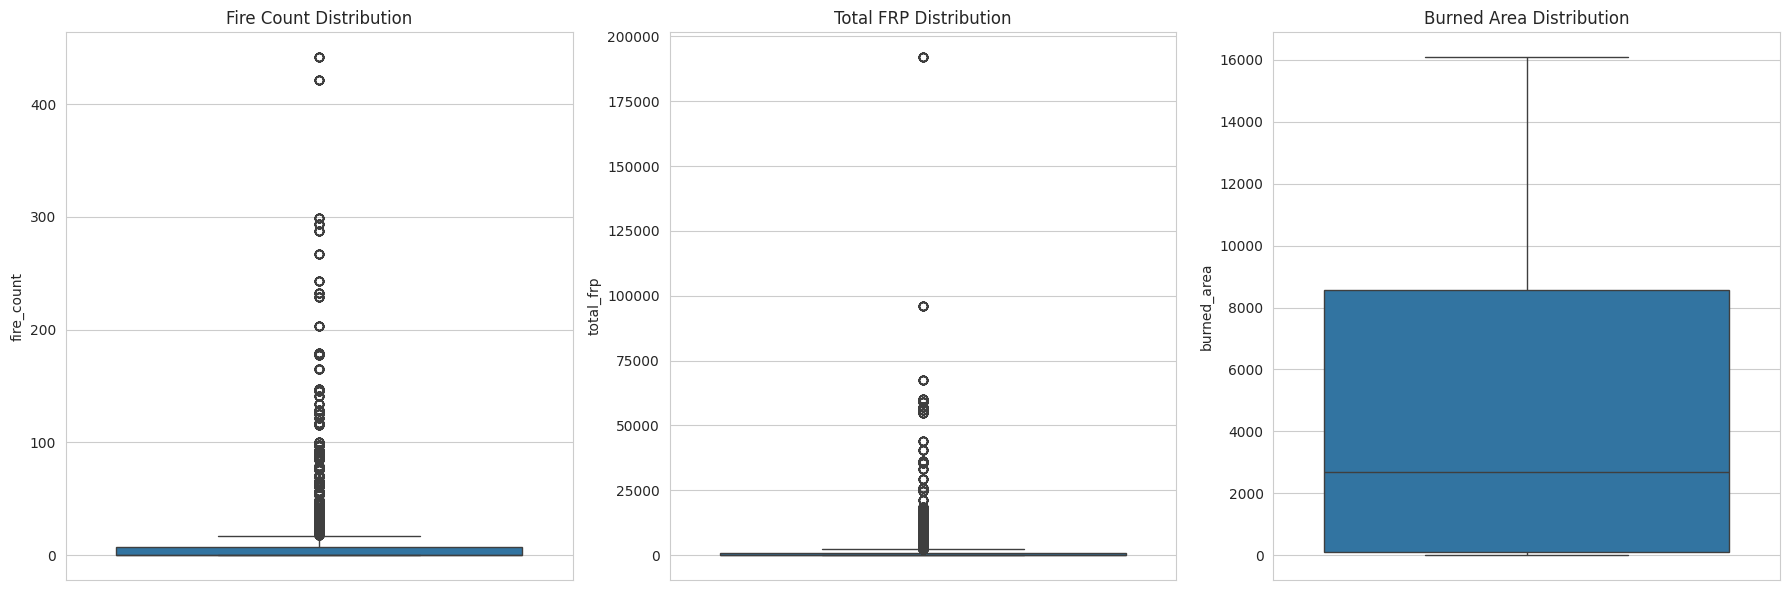

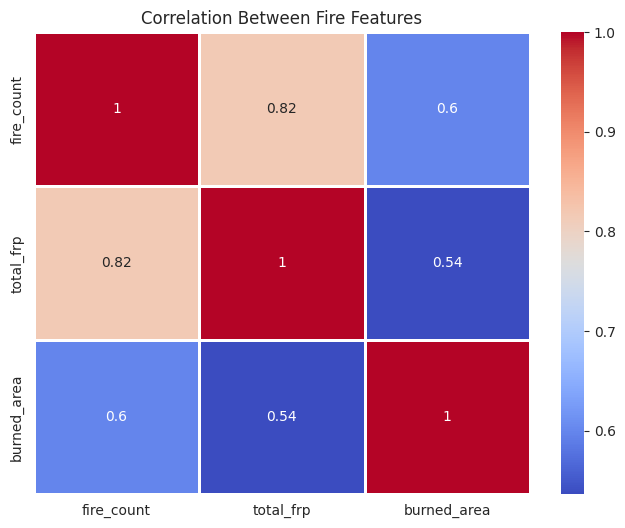

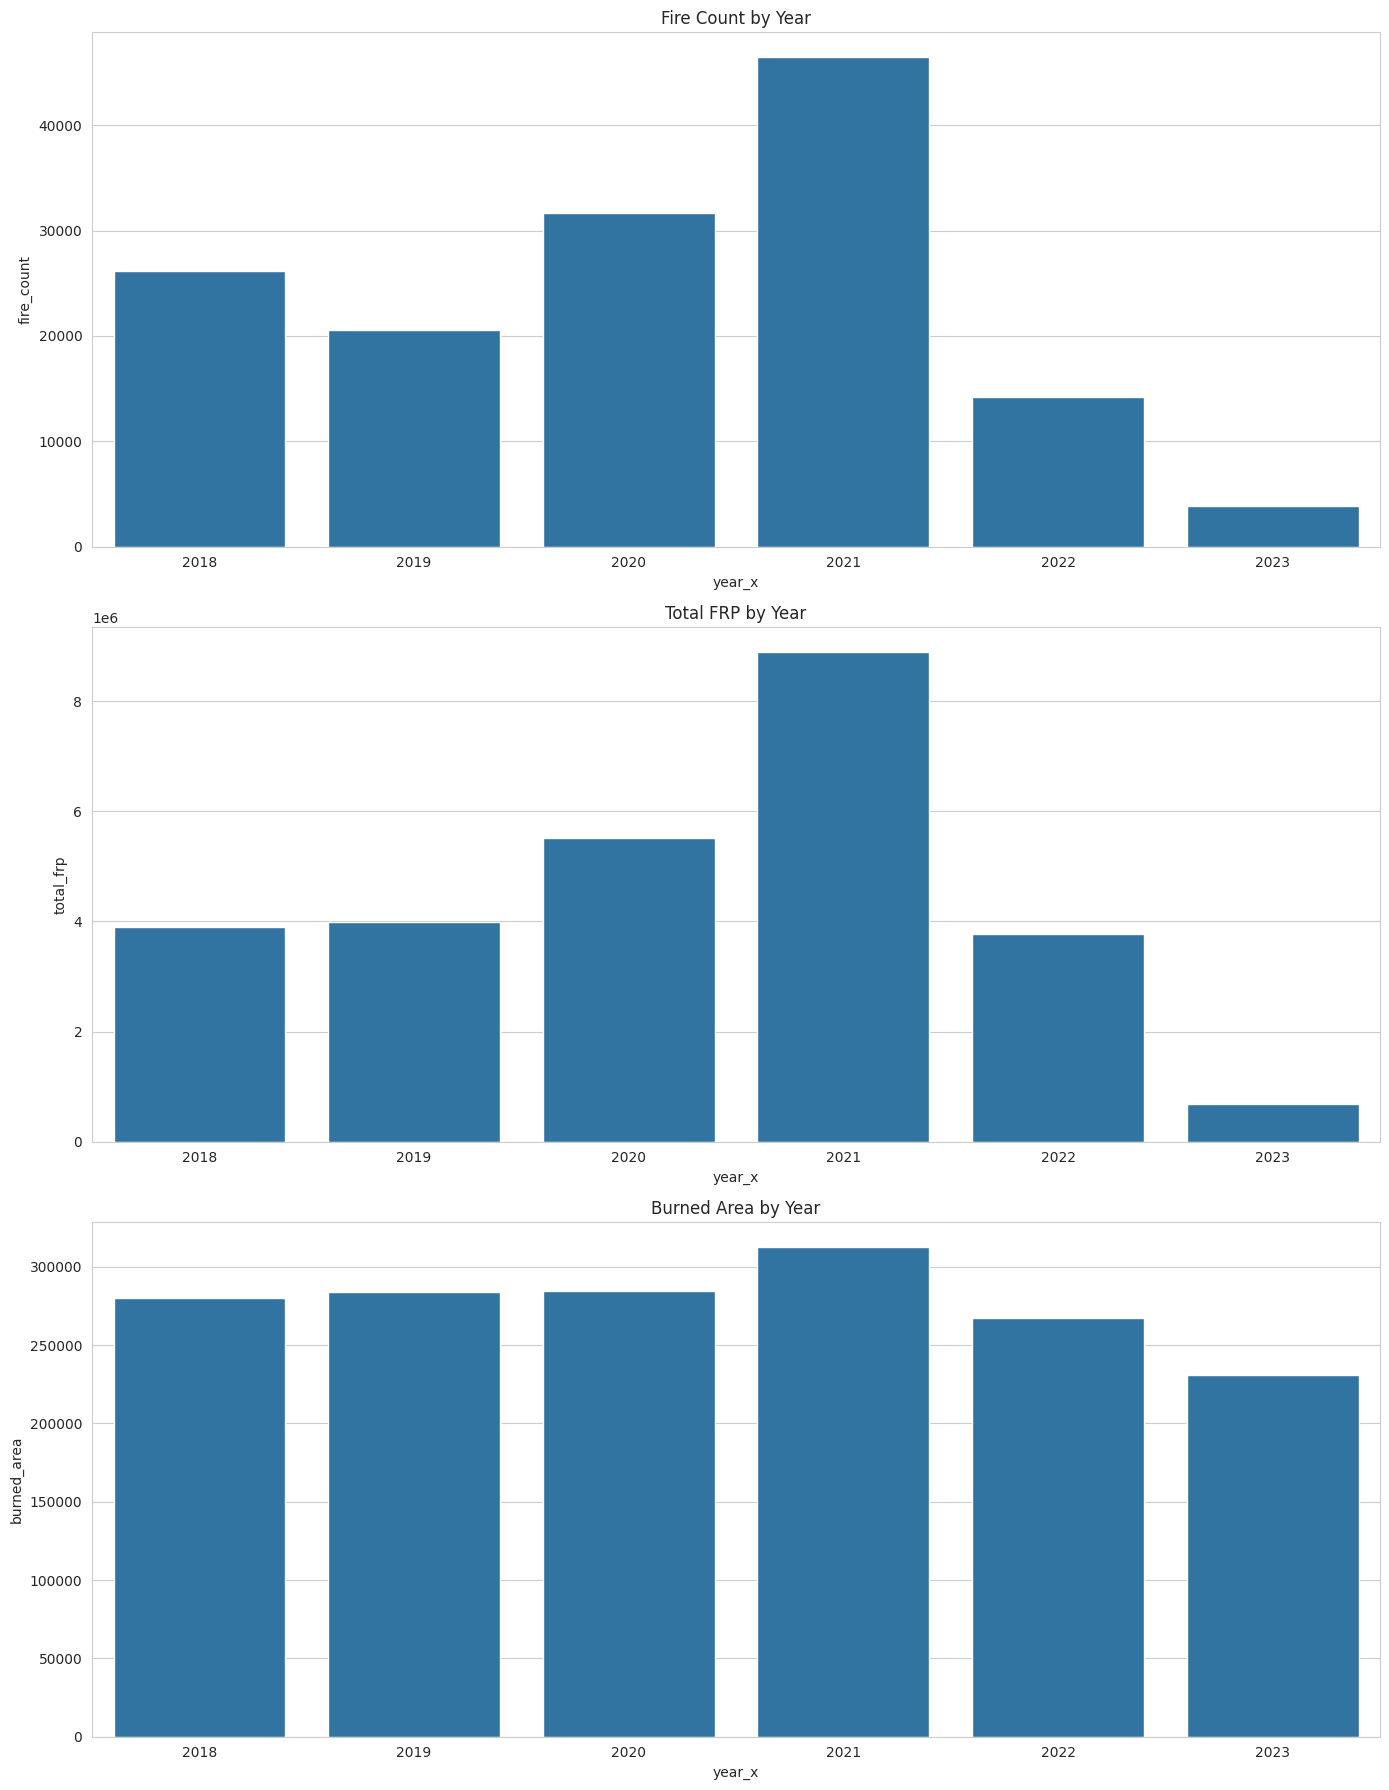


Yearly Growth Rates (%)
   year_x  fire_count_growth_%  frp_growth_%  burned_area_growth_%
0    2018                  NaN           NaN                   NaN
1    2019           -21.341527      2.272415              1.243918
2    2020            53.884356     38.420259              0.342864
3    2021            46.670500     61.165225              9.824318
4    2022           -69.351449    -57.562293            -14.544974
5    2023           -72.660833    -81.999901            -13.496854


In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load dataset
file_path = '/content/drive/MyDrive/fire_pollution_dataset_daily_cleaned.csv'
df = pd.read_csv(file_path)

#basic preprocessing
# If year_x is float/object convert to int
df['year_x'] = df['year_x'].astype(int)

#aggregate by year
yearly = df.groupby('year_x')[['fire_count', 'total_frp', 'burned_area']].agg([
    'sum',
    'mean',
    'max',
    'min'
])

print(yearly)

#reset index for easier plotting
yearly_sum = df.groupby('year_x')[['fire_count', 'total_frp', 'burned_area']].sum().reset_index()
yearly_mean = df.groupby('year_x')[['fire_count', 'total_frp', 'burned_area']].mean().reset_index()

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# 1. fire count across years
plt.figure()
sns.lineplot(data=yearly_sum, x='year_x', y='fire_count', marker='o', linewidth=3)

plt.title('Year-wise Total Fire Count', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Fire Count')
plt.xticks(rotation=45)
plt.show()

# 2. Total FRP across years
plt.figure()
sns.lineplot(data=yearly_sum, x='year_x', y='total_frp', marker='o', linewidth=3)

plt.title('Year-wise Total FRP', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Total FRP')
plt.xticks(rotation=45)
plt.show()

#3. Burned area across years
plt.figure()
sns.lineplot(data=yearly_sum, x='year_x', y='burned_area', marker='o', linewidth=3)

plt.title('Year-wise Burned Area', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Burned Area')
plt.xticks(rotation=45)
plt.show()

#4. comparison plot (normalized)
comparison = yearly_sum.copy()

comparison['fire_count'] = comparison['fire_count'] / comparison['fire_count'].max()
comparison['total_frp'] = comparison['total_frp'] / comparison['total_frp'].max()
comparison['burned_area'] = comparison['burned_area'] / comparison['burned_area'].max()

plt.figure(figsize=(14,7))

plt.plot(comparison['year_x'], comparison['fire_count'],
         marker='o', linewidth=3, label='Fire Count')

plt.plot(comparison['year_x'], comparison['total_frp'],
         marker='s', linewidth=3, label='Total FRP')

plt.plot(comparison['year_x'], comparison['burned_area'],
         marker='^', linewidth=3, label='Burned Area')

plt.title('Normalized Comparison Across Years', fontsize=18)
plt.xlabel('Year')
plt.ylabel('Normalized Value')
plt.legend()
plt.grid(True)
plt.show()

#5. Box plots to show distribution
fig, axes = plt.subplots(1, 3, figsize=(18,6))

sns.boxplot(y=df['fire_count'], ax=axes[0])
axes[0].set_title('Fire Count Distribution')

sns.boxplot(y=df['total_frp'], ax=axes[1])
axes[1].set_title('Total FRP Distribution')

sns.boxplot(y=df['burned_area'], ax=axes[2])
axes[2].set_title('Burned Area Distribution')

plt.tight_layout()
plt.show()

# 6. Correlation heatmap
plt.figure(figsize=(8,6))

corr = df[['fire_count', 'total_frp', 'burned_area']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=1)

plt.title('Correlation Between Fire Features')
plt.show()

# 7. Bar plots for yearly totals
fig, axes = plt.subplots(3, 1, figsize=(14,18))

sns.barplot(data=yearly_sum, x='year_x', y='fire_count', ax=axes[0])
axes[0].set_title('Fire Count by Year')

sns.barplot(data=yearly_sum, x='year_x', y='total_frp', ax=axes[1])
axes[1].set_title('Total FRP by Year')

sns.barplot(data=yearly_sum, x='year_x', y='burned_area', ax=axes[2])
axes[2].set_title('Burned Area by Year')

plt.tight_layout()
plt.show()

# 8. Yearly growth rates
growth = yearly_sum.copy()

growth['fire_count_growth_%'] = growth['fire_count'].pct_change() * 100
growth['frp_growth_%'] = growth['total_frp'].pct_change() * 100
growth['burned_area_growth_%'] = growth['burned_area'].pct_change() * 100

print("\nYearly Growth Rates (%)")
print(growth[['year_x',
              'fire_count_growth_%',
              'frp_growth_%',
              'burned_area_growth_%']])

### Stubble Burning Activity Trends (2018–2023)

The yearly growth statistics indicate substantial inter-annual variability in stubble burning activity across Punjab and Haryana during the study period. Following a moderate decline in fire count in 2019 (−21.3%), fire activity increased sharply in 2020 (+53.9%) and 2021 (+46.7%), accompanied by strong increases in Fire Radiative Power (FRP) and burned area.

Among all years, 2021 represents the peak burning season, with FRP increasing by approximately 61.2% and burned area increasing by nearly 9.8% relative to the previous year, indicating both more intense and spatially extensive burning activity.

In contrast, 2022 and 2023 show substantial declines across all fire metrics. Fire count decreased by approximately 69.4% in 2022 and 72.7% in 2023, while FRP dropped by 57.6% and 82.0% respectively. Burned area also declined during these years, suggesting a marked reduction in overall burning intensity compared to the 2020–2021 peak period.

Overall, the trends demonstrate that stubble burning activity exhibits strong year-to-year variability, with a major intensification during 2020–2021 followed by a pronounced decline after 2021. The consistent behaviour across fire count, FRP, and burned area indicates strong agreement among the different fire activity indicators.

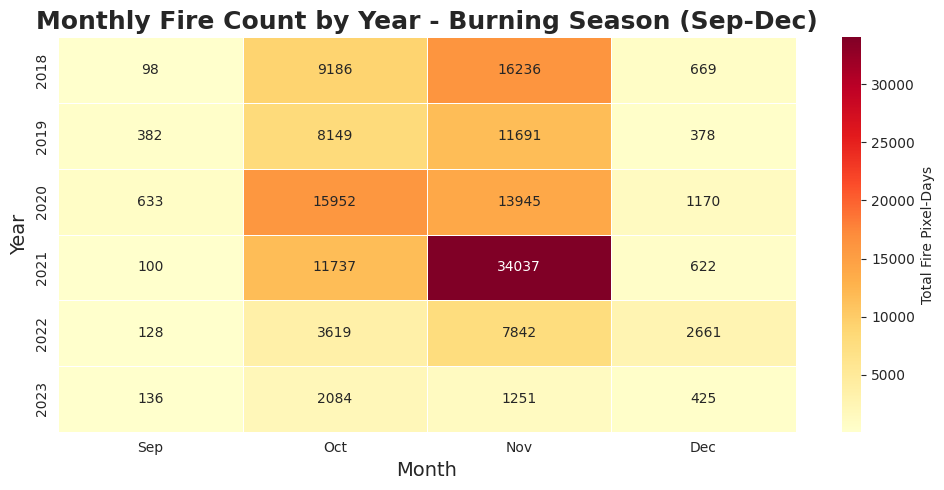

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
file_path = '/content/drive/MyDrive/fire_pollution_dataset_daily_cleaned.csv'
df = pd.read_csv(file_path)

# ensure date is datetimetype
df['date'] = pd.to_datetime(df['date'])

# extract month name for easier filtering
df['month'] = df['date'].dt.strftime('%b')

# filter to only burning season months
burning_months = ['Sep', 'Oct', 'Nov', 'Dec']

df = df[df['month'].isin(burning_months)]

# create pivot table for heatmap
heatmap_data = df.pivot_table(
    values='fire_count',
    index='year_x',
    columns='month',
    aggfunc='sum'
)

# reorder columns to ensure correct month order
heatmap_data = heatmap_data[burning_months]

# plot heatmap
plt.figure(figsize=(10, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Total Fire Pixel-Days'}
)

plt.title(
    'Monthly Fire Count by Year - Burning Season (Sep-Dec)',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Month', fontsize=14)
plt.ylabel('Year', fontsize=14)

plt.tight_layout()
plt.show()

### Monthly Fire Count Distribution (Sep–Dec, 2018–2023)

The heatmap illustrates the monthly distribution of fire detections (pixel-days) across the stubble burning season from September to December for each year between 2018 and 2023. A strong seasonal concentration is evident, with fire activity consistently increasing from September into October and peaking sharply in November.

Among all years, 2021 exhibits the most intense burning activity, with November recording approximately 34,037 fire pixel-days — the highest value in the dataset. Elevated November activity is also observed in 2018 (16,236), 2019 (11,691), and 2020 (13,945), confirming that November represents the core period of stubble burning across the Indo-Gangetic Plain.

October also shows substantial fire activity, particularly in 2020 (15,952) and 2021 (11,737), indicating an early intensification of residue burning during those years. In contrast, September and December consistently exhibit much lower fire counts, suggesting that large-scale burning remains concentrated within a relatively narrow post-harvest window.

A pronounced decline in fire activity is observed after 2021. Both 2022 and 2023 show substantially lower October and November fire counts compared to earlier years, indicating reduced burning intensity during the later part of the study period.

Overall, the monthly distribution highlights a highly seasonal and episodic burning pattern, with November emerging as the dominant month contributing to regional biomass burning emissions and likely air quality impacts over NCR.

# Pollution Anomalies in NCR




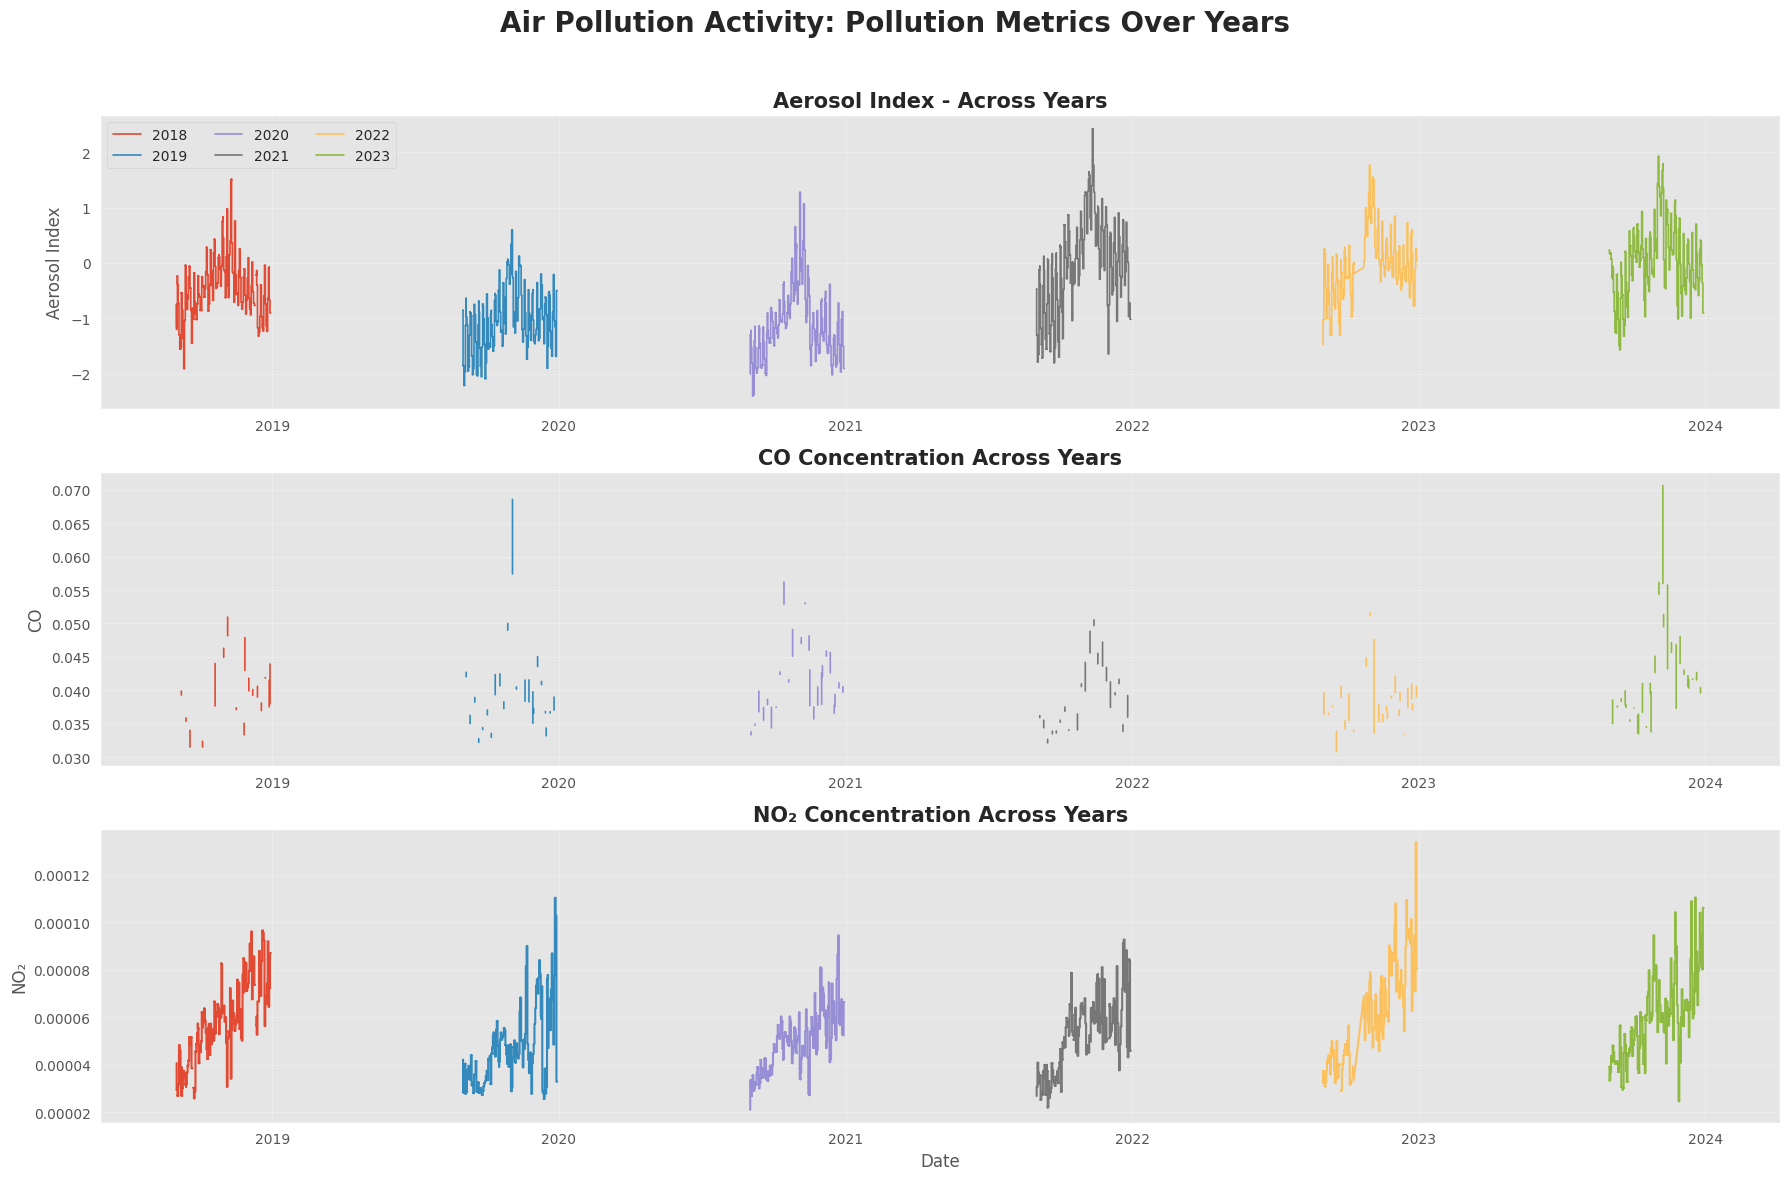

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# load dataset
file_path = '/content/drive/MyDrive/fire_pollution_dataset_daily_cleaned.csv'
df = pd.read_csv(file_path)

df['date'] = pd.to_datetime(df['date'])

df = df[['date', 'year_y', 'aerosol_index', 'co', 'no2']]

df['year_y'] = df['year_y'].astype(int)

plt.style.use('ggplot')

fig, axes = plt.subplots(
    3, 1,
    figsize=(18, 12),
    sharex=False
)

years = sorted(df['year_y'].unique())

# aerosol index across years
for year in years:

    yearly_data = df[df['year_y'] == year]

    axes[0].plot(
        yearly_data['date'],
        yearly_data['aerosol_index'],
        linewidth=1.2,
        label=str(year)
    )

axes[0].set_title(
    'Aerosol Index - Across Years',
    fontsize=15,
    weight='bold'
)

axes[0].set_ylabel('Aerosol Index')
axes[0].legend(ncol=3)
axes[0].grid(True, alpha=0.3)

# CO concentrations across years
for year in years:

    yearly_data = df[df['year_y'] == year]

    axes[1].plot(
        yearly_data['date'],
        yearly_data['co'],
        linewidth=1.2,
        label=str(year)
    )

axes[1].set_title(
    'CO Concentration Across Years',
    fontsize=15,
    weight='bold'
)

axes[1].set_ylabel('CO')
axes[1].grid(True, alpha=0.3)

# NO2 concentrations across years
for year in years:

    yearly_data = df[df['year_y'] == year]

    axes[2].plot(
        yearly_data['date'],
        yearly_data['no2'],
        linewidth=1.5,
        label=str(year)
    )

axes[2].set_title(
    'NO₂ Concentration Across Years',
    fontsize=15,
    weight='bold'
)

axes[2].set_ylabel('NO₂')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

fig.suptitle(
    'Air Pollution Activity: Pollution Metrics Over Years',
    fontsize=20,
    weight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

### Temporal Evolution of Air Pollution Metrics (2018–2023)

The figure illustrates the temporal evolution of three major air pollution indicators over NCR during the burning seasons (September–December) from 2018 to 2023: Aerosol Index (AI), Carbon Monoxide (CO), and Nitrogen Dioxide (NO₂).

Across all years, the Aerosol Index exhibits pronounced short-term fluctuations and frequent positive spikes during peak burning months, indicating episodic increases in smoke-related aerosol loading. Particularly elevated aerosol activity is observed during 2021 and 2023, reflecting periods of intensified atmospheric particulate pollution associated with biomass burning and stagnant meteorological conditions.

CO concentrations remain comparatively stable across years, generally varying within a narrower range relative to AI and NO₂. However, occasional sharp increases are visible during high pollution episodes, especially in 2019 and 2023. This smoother temporal behaviour is consistent with CO’s longer atmospheric lifetime, which allows accumulation and persistence over extended periods.

NO₂ concentrations display clearer upward episodic patterns within each burning season, with strong day-to-day variability and several high-concentration events. Elevated NO₂ peaks are particularly noticeable during 2022 and 2023, suggesting enhanced combustion-related emissions and limited atmospheric dispersion during these periods.

Overall, all three pollutants exhibit seasonal increases during the post-harvest burning period, supporting the relationship between biomass burning activity and deteriorating air quality over NCR. While aerosol index and NO₂ show sharper short-term responses to pollution episodes, CO demonstrates a more gradual and persistent accumulation pattern due to its longer atmospheric residence time.

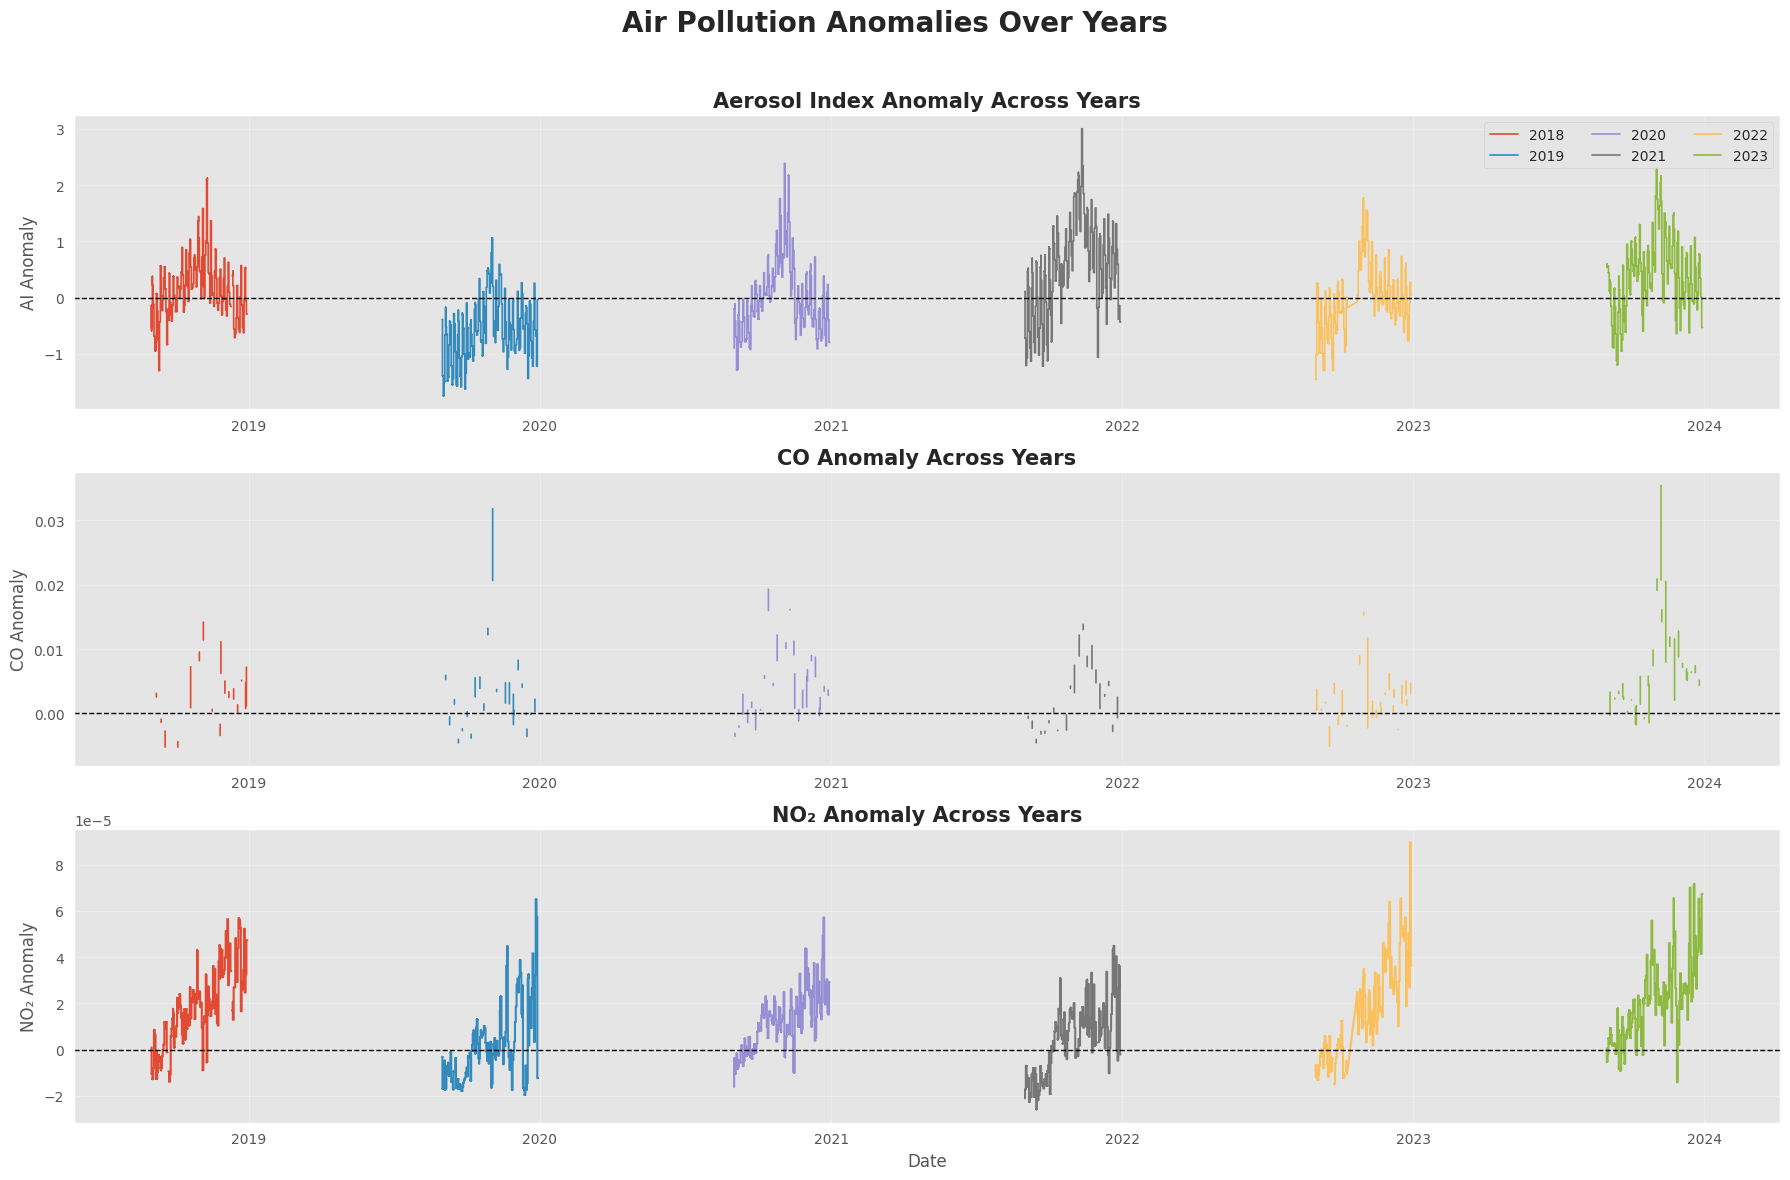

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# load dataset
file_path = '/content/drive/MyDrive/fire_pollution_dataset_daily_cleaned.csv'
df = pd.read_csv(file_path)

df['date'] = pd.to_datetime(df['date'])

df = df[[
    'date',
    'year_y',
    'ai_anomaly',
    'co_anomaly',
    'no2_anomaly'
]]

df['year_y'] = df['year_y'].astype(int)

plt.style.use('ggplot')

fig, axes = plt.subplots(
    3, 1,
    figsize=(18, 12),
    sharex=False
)

years = sorted(df['year_y'].unique())

# 1. AEROSOL INDEX ANOMALY
for year in years:

    yearly_data = df[df['year_y'] == year]

    axes[0].plot(
        yearly_data['date'],
        yearly_data['ai_anomaly'],
        linewidth=1.2,
        label=str(year)
    )

axes[0].axhline(
    0,
    linestyle='--',
    color='black',
    linewidth=1
)

axes[0].set_title(
    'Aerosol Index Anomaly Across Years',
    fontsize=15,
    weight='bold'
)

axes[0].set_ylabel('AI Anomaly')
axes[0].legend(ncol=3)
axes[0].grid(True, alpha=0.3)

# 2. CO ANOMALY
for year in years:

    yearly_data = df[df['year_y'] == year]

    axes[1].plot(
        yearly_data['date'],
        yearly_data['co_anomaly'],
        linewidth=1.2,
        label=str(year)
    )

axes[1].axhline(
    0,
    linestyle='--',
    color='black',
    linewidth=1
)

axes[1].set_title(
    'CO Anomaly Across Years',
    fontsize=15,
    weight='bold'
)

axes[1].set_ylabel('CO Anomaly')
axes[1].grid(True, alpha=0.3)

# 3. NO2 ANOMALY
for year in years:

    yearly_data = df[df['year_y'] == year]

    axes[2].plot(
        yearly_data['date'],
        yearly_data['no2_anomaly'],
        linewidth=1.5,
        label=str(year)
    )

axes[2].axhline(
    0,
    linestyle='--',
    color='black',
    linewidth=1
)

axes[2].set_title(
    'NO₂ Anomaly Across Years',
    fontsize=15,
    weight='bold'
)

axes[2].set_ylabel('NO₂ Anomaly')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)

fig.suptitle(
    'Air Pollution Anomalies Over Years',
    fontsize=20,
    weight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

### Pollution Anomalies in NCR During Burning Season (2018–2023)

The figure presents the temporal evolution of Aerosol Index (AI), CO, and NO₂ anomalies over NCR during the burning seasons (September–December) from 2018 to 2023. The dashed horizontal line represents the zero-anomaly baseline, where positive values indicate pollution levels above normal background conditions and negative values indicate below-baseline conditions.

Across all years, pollution anomalies increase substantially during the peak burning months of October and November, consistent with periods of intensified stubble burning activity in Punjab and Haryana. This seasonal rise is most clearly visible in NO₂ and aerosol index anomalies, both of which exhibit strong episodic peaks during active burning periods.

The Aerosol Index anomaly shows pronounced positive spikes, particularly during 2021 and 2023, indicating elevated smoke aerosol loading and severe particulate pollution episodes. Several periods also exhibit negative anomalies, reflecting cleaner atmospheric conditions outside major burning events.

CO anomalies display comparatively smoother and lower-amplitude variations, remaining positive during most peak burning periods but with fewer extreme spikes. This behaviour is consistent with the longer atmospheric lifetime of CO, which leads to gradual accumulation and persistence in the atmosphere rather than sharp short-term fluctuations.

NO₂ anomalies exhibit strong day-to-day variability and sustained positive increases during peak burning periods across nearly all years. The largest anomaly peaks are observed during 2022 and 2023, suggesting intensified combustion-related pollution and reduced atmospheric dispersion during those seasons.

Overall, the simultaneous increase in aerosol, CO, and NO₂ anomalies during the post-harvest months provides strong evidence of a seasonal deterioration in air quality over NCR associated with regional biomass burning activity.

       aerosol_index                                      co            \
                 sum      mean       max       min       sum      mean   
year_y                                                                   
2018     -802.066576 -0.476570  1.514336 -1.907366  5.351368  0.039061   
2019    -1767.609278 -1.036113  0.593507 -2.213001  5.707863  0.039915   
2020    -1888.997721 -1.107917  1.278238 -2.399877  6.150961  0.042130   
2021      -98.716002 -0.057898  2.424466 -1.802483  5.550768  0.039648   
2022      -61.514246 -0.040022  1.766036 -1.465155  5.083598  0.038223   
2023       19.034942  0.011158  1.928527 -1.567890  6.132013  0.041433   

                                 no2                                
             max       min       sum      mean       max       min  
year_y                                                              
2018    0.051209  0.030680  0.097886  0.000059  0.000097  0.000026  
2019    0.068580  0.030702  0.080484  0.000047  0.000110 

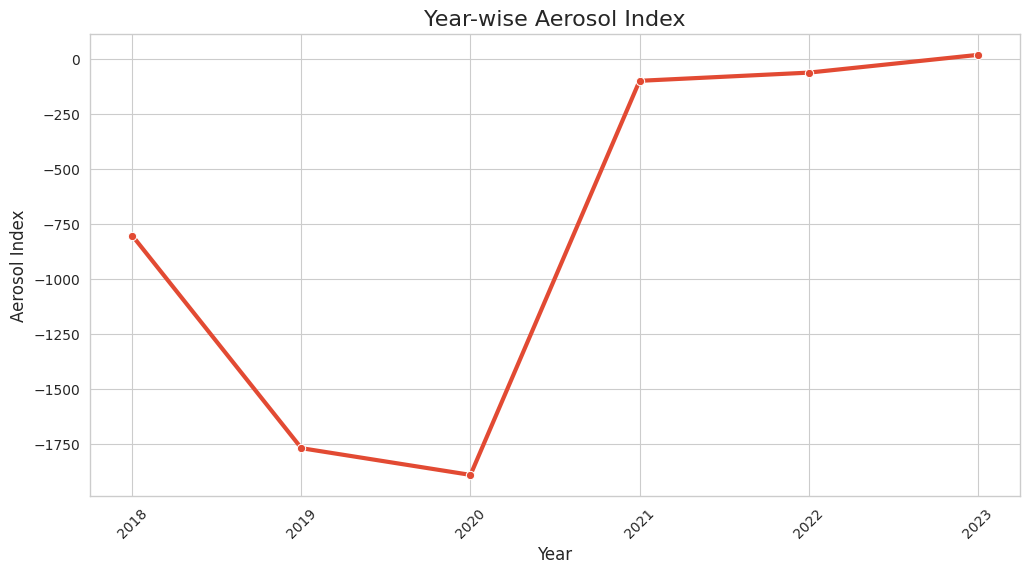

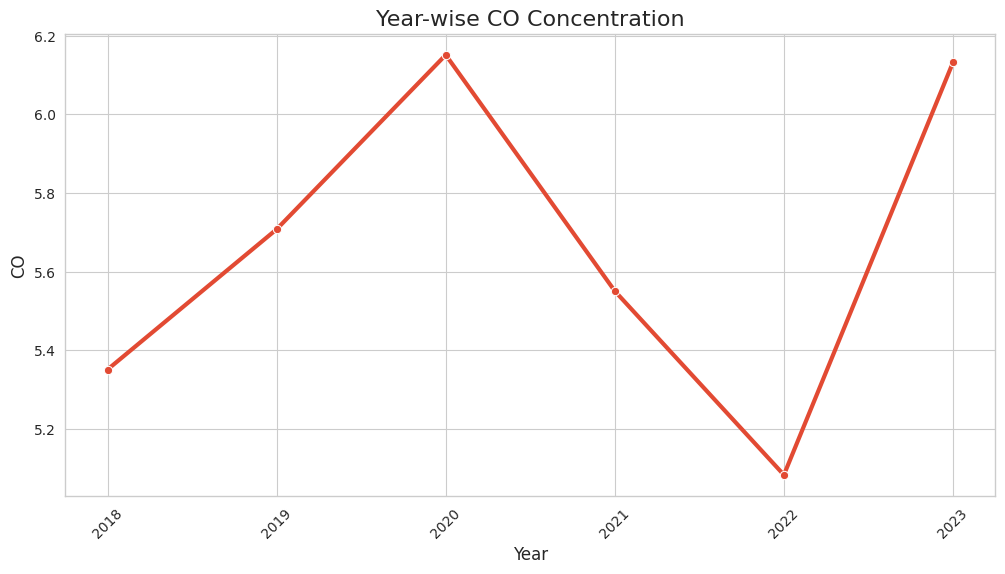

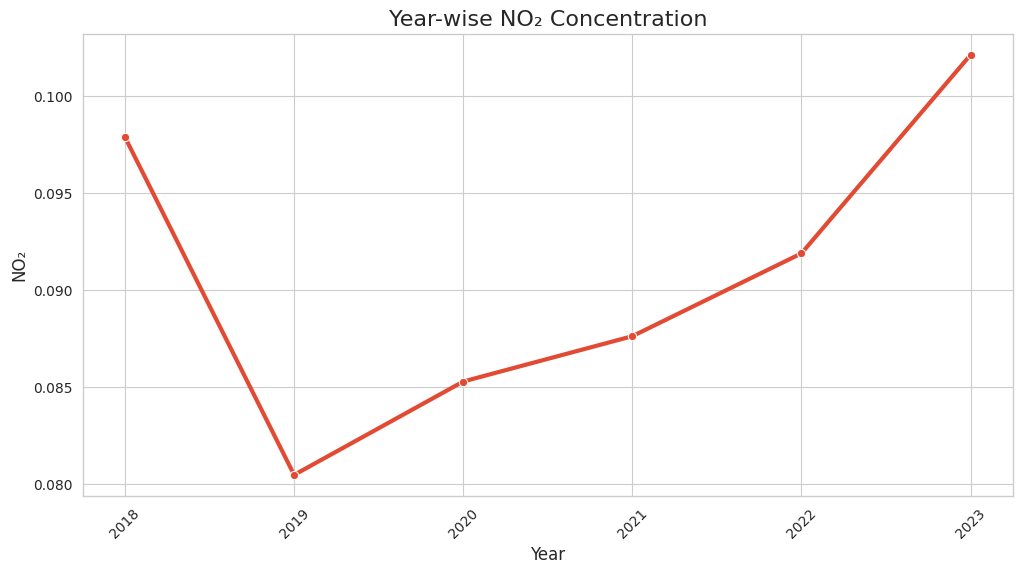

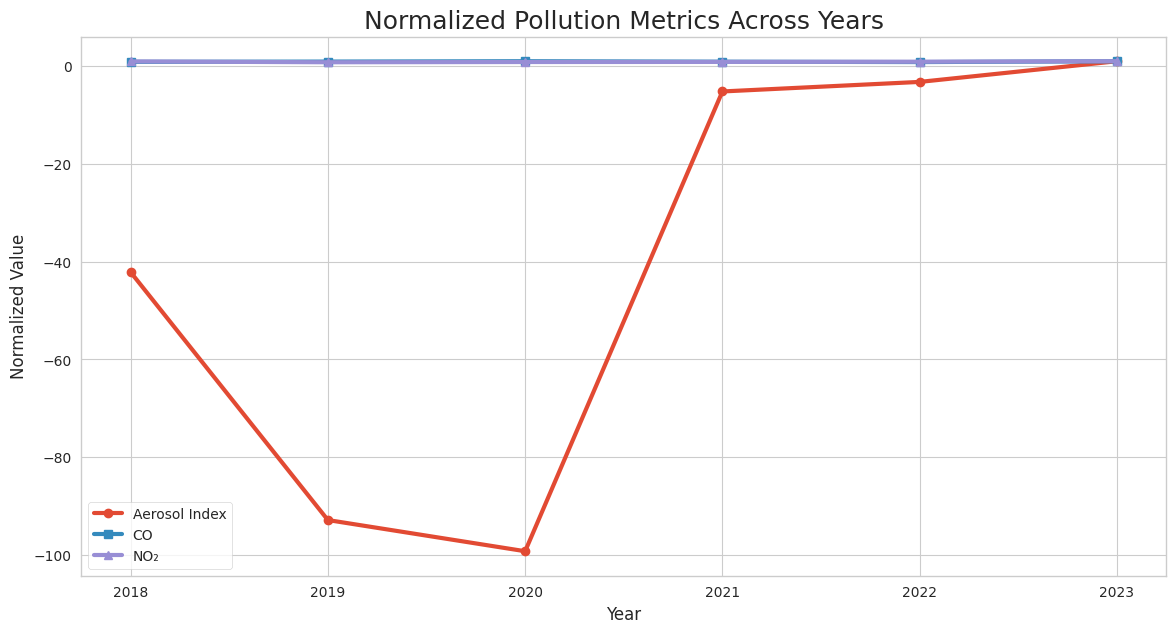

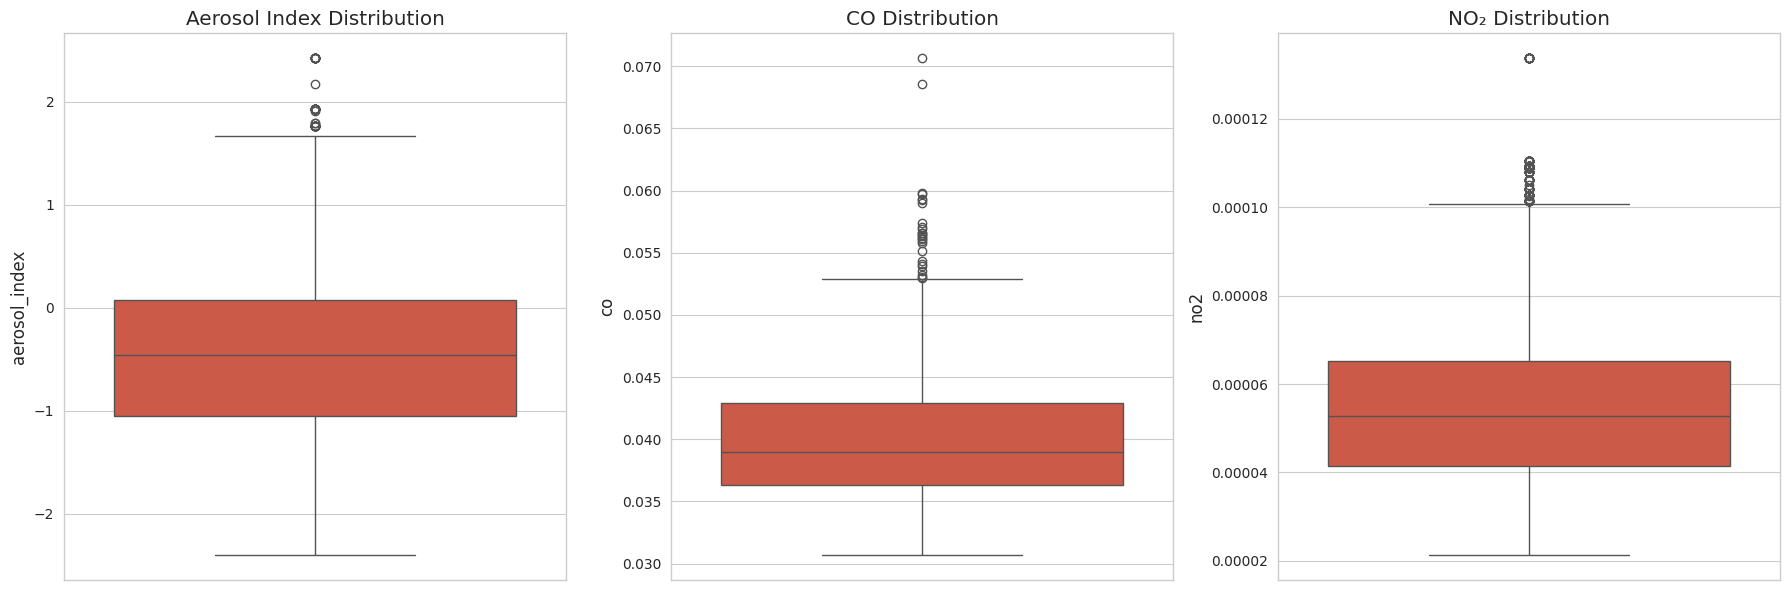

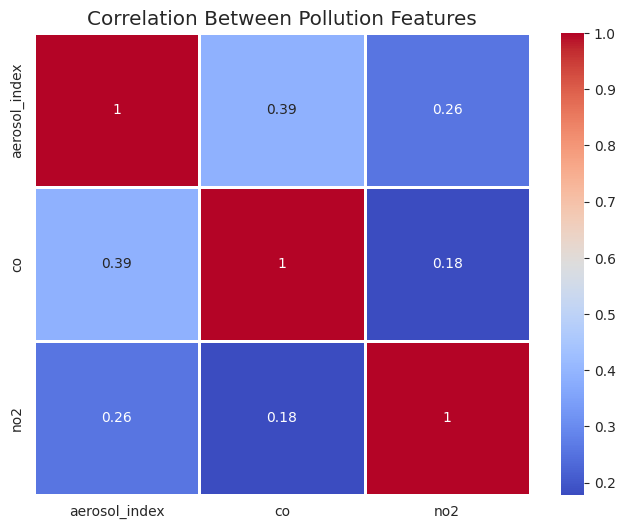

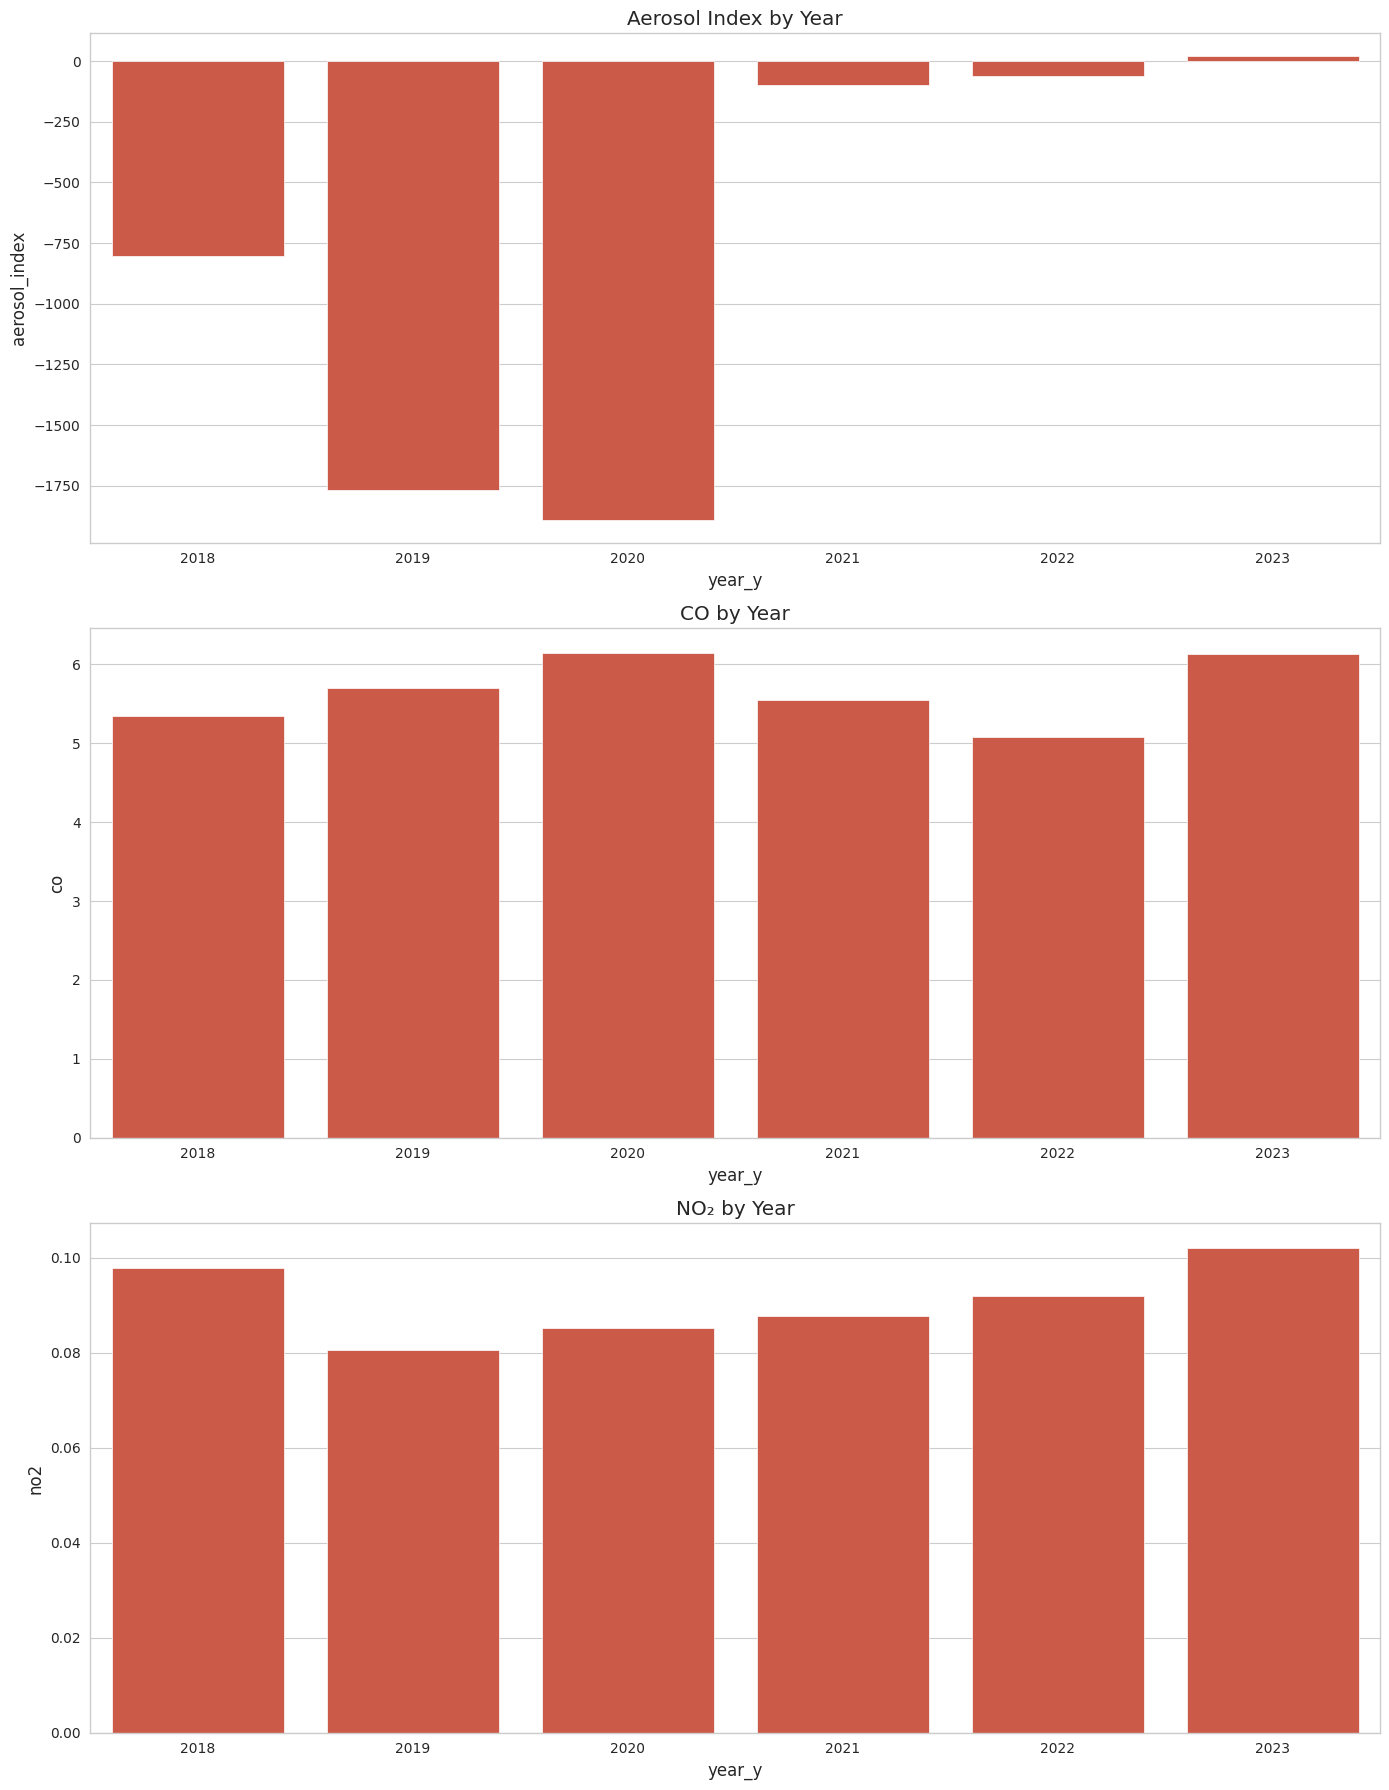


Yearly Growth Rates (%)
   year_y  aerosol_growth_%  co_growth_%  no2_growth_%
0    2018               NaN          NaN           NaN
1    2019        120.381865     6.661759    -17.778585
2    2020          6.867380     7.762940      5.980758
3    2021        -94.774160    -9.757713      2.739030
4    2022        -37.685639    -8.416316      4.871198
5    2023       -130.943957    20.623489     11.133873


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/drive/MyDrive/fire_pollution_dataset_daily_cleaned.csv'
df = pd.read_csv(file_path)

df['year_y'] = df['year_y'].astype(int)

yearly = df.groupby('year_y')[['aerosol_index', 'co', 'no2']].agg([
    'sum',
    'mean',
    'max',
    'min'
])

print(yearly)

yearly_sum = df.groupby('year_y')[['aerosol_index', 'co', 'no2']].sum().reset_index()
yearly_mean = df.groupby('year_y')[['aerosol_index', 'co', 'no2']].mean().reset_index()


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

plt.figure()

sns.lineplot(
    data=yearly_sum,
    x='year_y',
    y='aerosol_index',
    marker='o',
    linewidth=3
)

plt.title('Year-wise Aerosol Index', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Aerosol Index')
plt.xticks(rotation=45)
plt.show()

plt.figure()

sns.lineplot(
    data=yearly_sum,
    x='year_y',
    y='co',
    marker='o',
    linewidth=3
)

plt.title('Year-wise CO Concentration', fontsize=16)
plt.xlabel('Year')
plt.ylabel('CO')
plt.xticks(rotation=45)
plt.show()

plt.figure()

sns.lineplot(
    data=yearly_sum,
    x='year_y',
    y='no2',
    marker='o',
    linewidth=3
)

plt.title('Year-wise NO₂ Concentration', fontsize=16)
plt.xlabel('Year')
plt.ylabel('NO₂')
plt.xticks(rotation=45)
plt.show()

comparison = yearly_sum.copy()

# Normalize values
comparison['aerosol_index'] = (
    comparison['aerosol_index'] /
    comparison['aerosol_index'].max()
)

comparison['co'] = (
    comparison['co'] /
    comparison['co'].max()
)

comparison['no2'] = (
    comparison['no2'] /
    comparison['no2'].max()
)

plt.figure(figsize=(14,7))

plt.plot(
    comparison['year_y'],
    comparison['aerosol_index'],
    marker='o',
    linewidth=3,
    label='Aerosol Index'
)

plt.plot(
    comparison['year_y'],
    comparison['co'],
    marker='s',
    linewidth=3,
    label='CO'
)

plt.plot(
    comparison['year_y'],
    comparison['no2'],
    marker='^',
    linewidth=3,
    label='NO₂'
)

plt.title('Normalized Pollution Metrics Across Years', fontsize=18)
plt.xlabel('Year')
plt.ylabel('Normalized Value')
plt.legend()
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18,6))

sns.boxplot(y=df['aerosol_index'], ax=axes[0])
axes[0].set_title('Aerosol Index Distribution')

sns.boxplot(y=df['co'], ax=axes[1])
axes[1].set_title('CO Distribution')

sns.boxplot(y=df['no2'], ax=axes[2])
axes[2].set_title('NO₂ Distribution')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))

corr = df[['aerosol_index', 'co', 'no2']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=1
)

plt.title('Correlation Between Pollution Features')
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14,18))

sns.barplot(
    data=yearly_sum,
    x='year_y',
    y='aerosol_index',
    ax=axes[0]
)

axes[0].set_title('Aerosol Index by Year')

sns.barplot(
    data=yearly_sum,
    x='year_y',
    y='co',
    ax=axes[1]
)

axes[1].set_title('CO by Year')

sns.barplot(
    data=yearly_sum,
    x='year_y',
    y='no2',
    ax=axes[2]
)

axes[2].set_title('NO₂ by Year')

plt.tight_layout()
plt.show()

growth = yearly_sum.copy()

growth['aerosol_growth_%'] = (
    growth['aerosol_index'].pct_change() * 100
)

growth['co_growth_%'] = (
    growth['co'].pct_change() * 100
)

growth['no2_growth_%'] = (
    growth['no2'].pct_change() * 100
)

print("\nYearly Growth Rates (%)")

print(
    growth[[
        'year_y',
        'aerosol_growth_%',
        'co_growth_%',
        'no2_growth_%'
    ]]
)

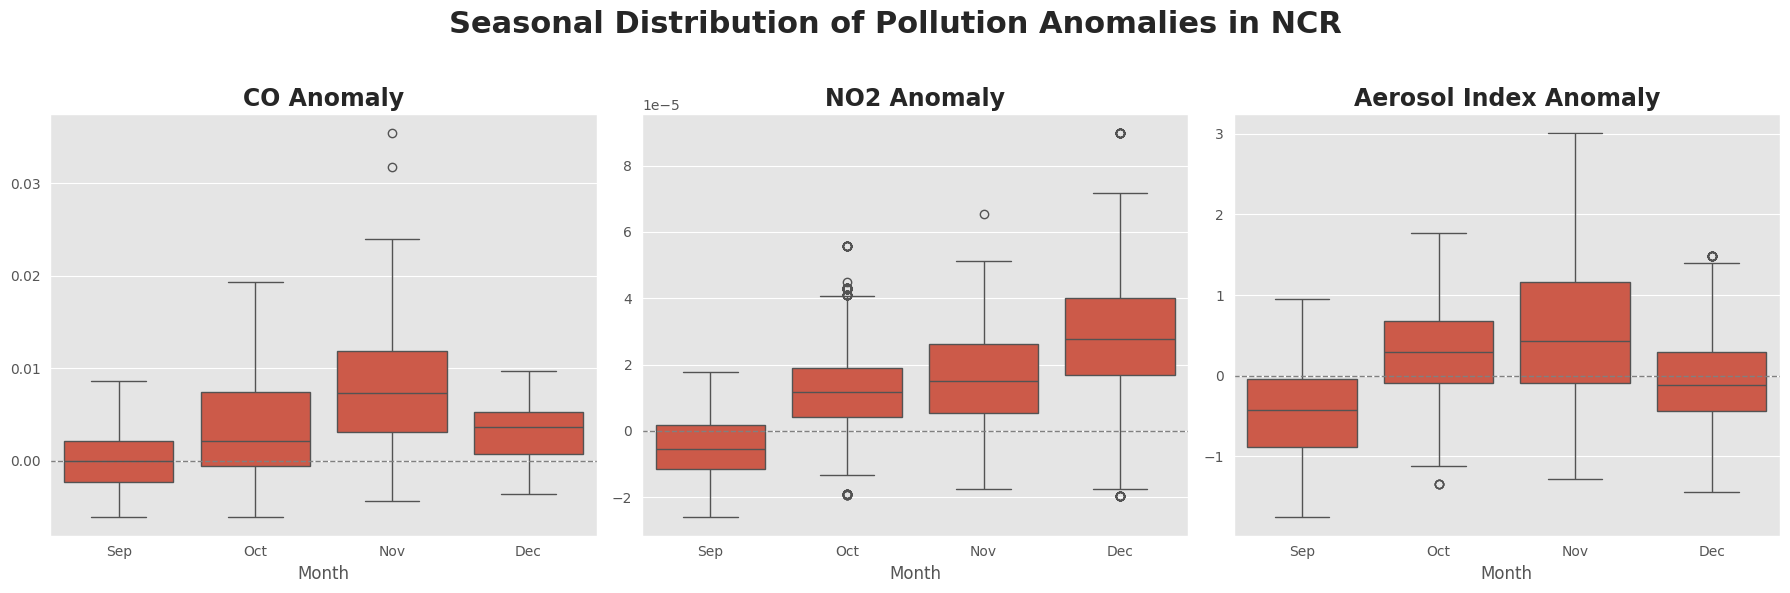

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/drive/MyDrive/fire_pollution_dataset_daily_cleaned.csv'
df = pd.read_csv(file_path)

df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.strftime('%b')

burning_months = ['Sep', 'Oct', 'Nov', 'Dec']

df = df[df['month'].isin(burning_months)]

df = df[[
    'month',
    'co_anomaly',
    'no2_anomaly',
    'ai_anomaly'
]]


plt.style.use('ggplot')

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

sns.boxplot(
    data=df,
    x='month',
    y='co_anomaly',
    order=burning_months,
    ax=axes[0]
)

axes[0].axhline(
    0,
    linestyle='--',
    color='gray',
    linewidth=1
)

axes[0].set_title(
    'CO Anomaly',
    fontsize=17,
    weight='bold'
)

axes[0].set_xlabel('Month')
axes[0].set_ylabel('')

sns.boxplot(
    data=df,
    x='month',
    y='no2_anomaly',
    order=burning_months,
    ax=axes[1]
)

axes[1].axhline(
    0,
    linestyle='--',
    color='gray',
    linewidth=1
)

axes[1].set_title(
    'NO2 Anomaly',
    fontsize=17,
    weight='bold'
)

axes[1].set_xlabel('Month')
axes[1].set_ylabel('')

sns.boxplot(
    data=df,
    x='month',
    y='ai_anomaly',
    order=burning_months,
    ax=axes[2]
)

axes[2].axhline(
    0,
    linestyle='--',
    color='gray',
    linewidth=1
)

axes[2].set_title(
    'Aerosol Index Anomaly',
    fontsize=17,
    weight='bold'
)

axes[2].set_xlabel('Month')
axes[2].set_ylabel('')

fig.suptitle(
    'Seasonal Distribution of Pollution Anomalies in NCR',
    fontsize=22,
    weight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

### Seasonal Distribution of Pollution Anomalies in NCR

The boxplots illustrate the monthly distribution of CO, NO₂, and Aerosol Index (AI) anomalies across the burning season months (September–December), aggregated over the full study period from 2018 to 2023.

A clear seasonal progression is observed across all pollutants, with anomaly levels generally increasing from September to November. November consistently exhibits the highest median values and the largest spread (interquartile range), indicating both elevated pollution levels and greater day-to-day variability during the peak burning period.

CO anomalies remain relatively close to the baseline in September but gradually increase through October and peak in November. The presence of several high positive outliers during November suggests episodic pollution accumulation events associated with intense biomass burning and stagnant atmospheric conditions.

NO₂ anomalies display a stronger and more systematic upward shift across the season. Median values increase steadily from negative or near-baseline conditions in September to strongly positive anomalies in November and December, indicating enhanced combustion-related emissions and sustained atmospheric pollution during the later part of the burning season.

The Aerosol Index anomaly exhibits the largest variability among the three pollutants. Positive median anomalies during October and November, along with several extreme upper outliers, indicate severe smoke aerosol loading during peak stubble burning periods. The wider spread of AI anomalies also reflects the episodic nature of particulate pollution and the influence of meteorological conditions on aerosol transport and accumulation.

Although December shows a slight reduction in variability for CO and aerosol anomalies, pollution levels remain elevated relative to September, suggesting that residual atmospheric pollution persists even after peak burning activity declines.

Overall, the seasonal distributions demonstrate a pronounced deterioration in air quality during October–November, strongly aligning with the timing of large-scale stubble burning activity in Punjab and Haryana.

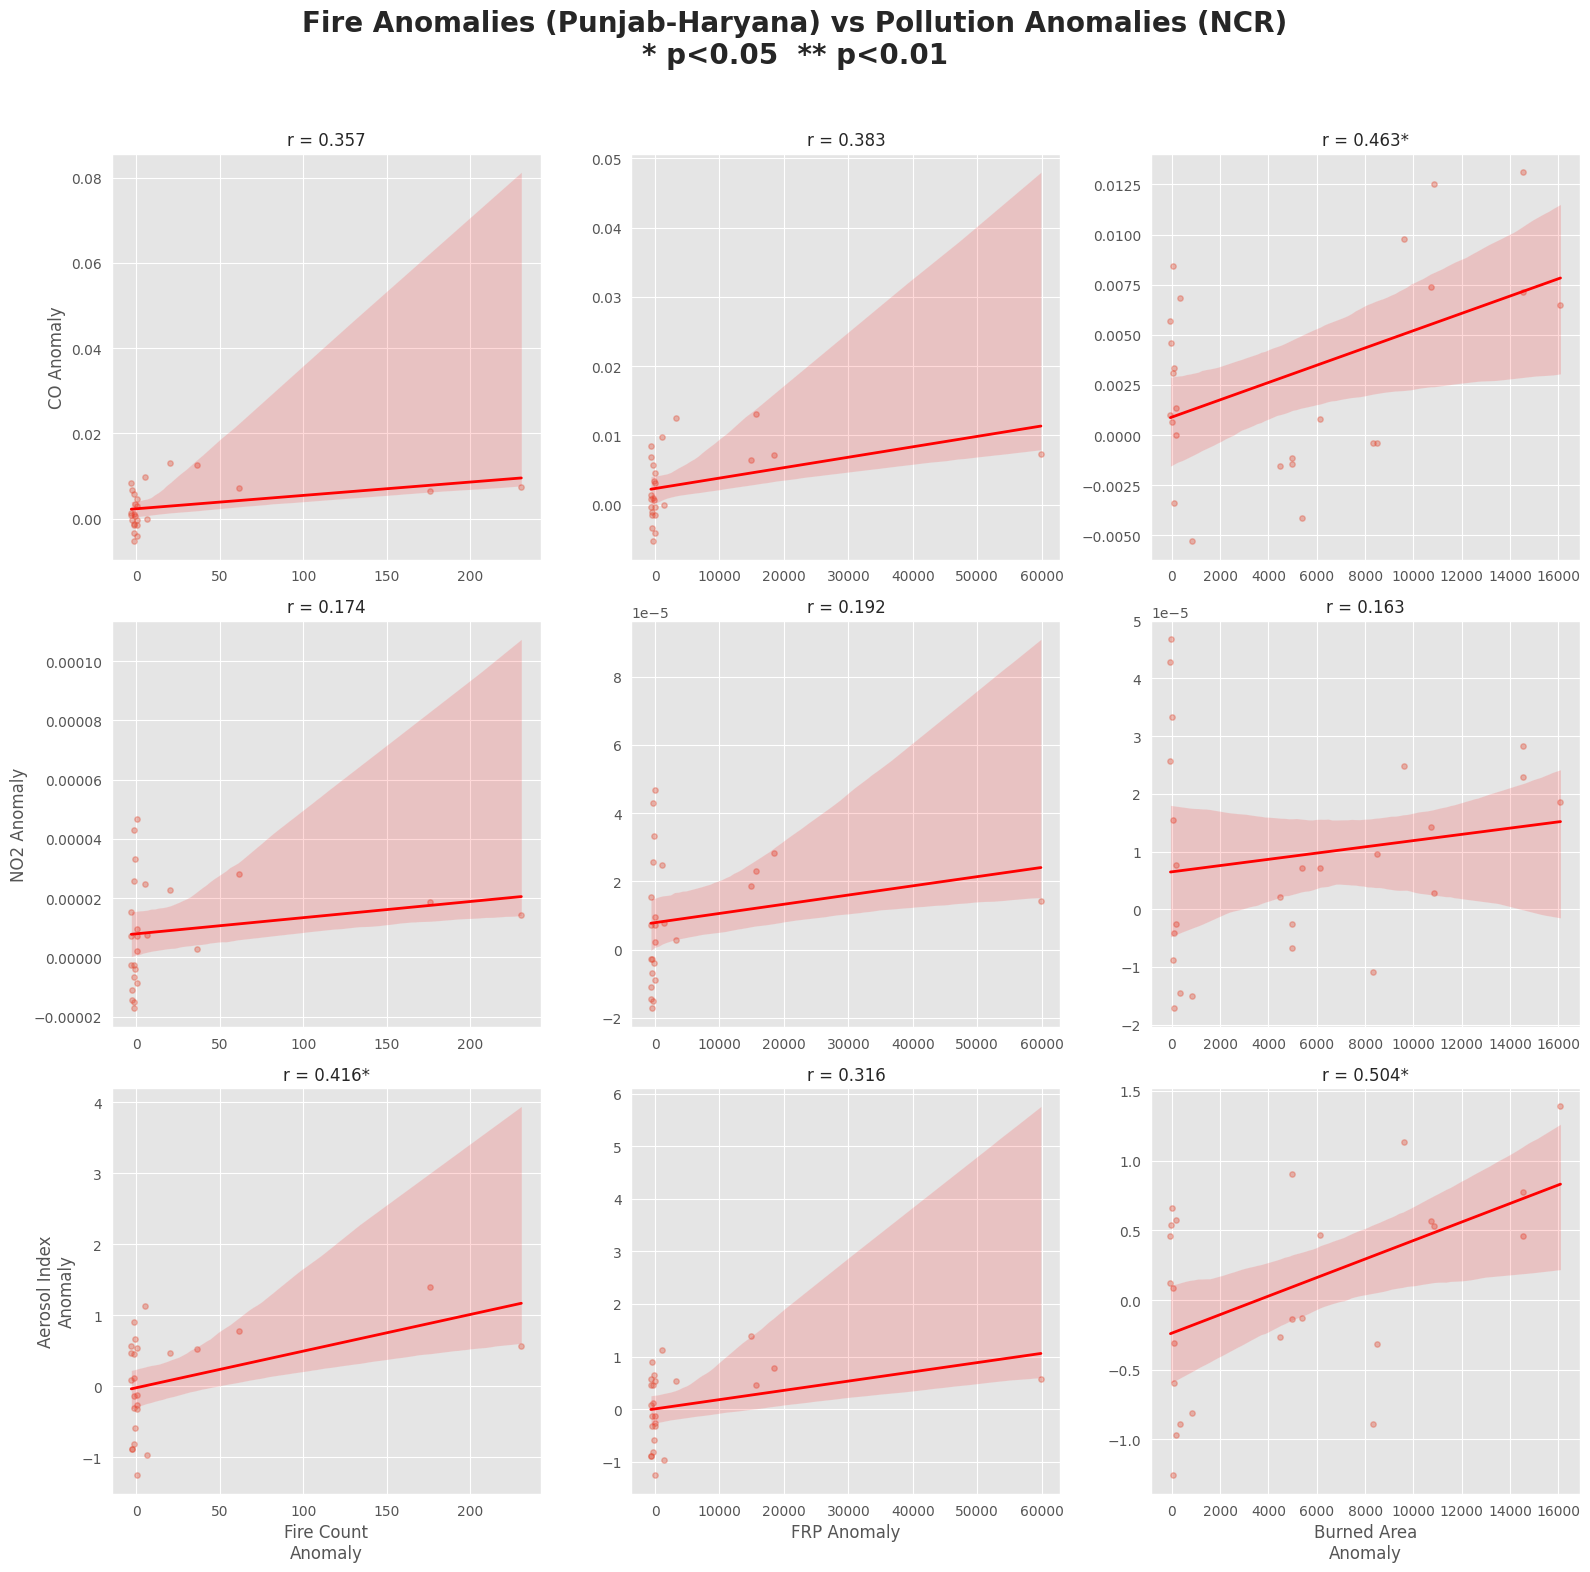

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

file_path = '/content/drive/MyDrive/fire_pollution_dataset_daily_cleaned.csv'
df = pd.read_csv(file_path)

fire_vars_anom = [
    'fire_anomaly',
    'frp_anomaly',
    'burn_anomaly'
]

poll_vars_anom = [
    'co_anomaly',
    'no2_anomaly',
    'ai_anomaly'
]

df = df[fire_vars_anom + poll_vars_anom]

df = df.dropna()

plt.style.use('ggplot')

fig, axes = plt.subplots(
    3, 3,
    figsize=(16, 16)
)

x_labels = [
    'Fire Count\nAnomaly',
    'FRP Anomaly',
    'Burned Area\nAnomaly'
]

y_labels = [
    'CO Anomaly',
    'NO2 Anomaly',
    'Aerosol Index\nAnomaly'
]

for i, y_col in enumerate(poll_vars_anom):

    for j, x_col in enumerate(fire_vars_anom):

        ax = axes[i, j]

        sns.regplot(
            data=df,
            x=x_col,
            y=y_col,
            ax=ax,
            scatter_kws={
                'alpha': 0.35,
                's': 15
            },
            line_kws={
                'color': 'red',
                'linewidth': 2
            }
        )

        r, p = pearsonr(df[x_col], df[y_col])

        if p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        ax.set_title(
            f'r = {r:.3f}{stars}',
            fontsize=12
        )

        if i == 2:
            ax.set_xlabel(
                x_labels[j],
                fontsize=12
            )
        else:
            ax.set_xlabel('')

        if j == 0:
            ax.set_ylabel(
                y_labels[i],
                fontsize=12
            )
        else:
            ax.set_ylabel('')

fig.suptitle(
    'Fire Anomalies (Punjab-Haryana) vs Pollution Anomalies (NCR)\n'
    '* p<0.05  ** p<0.01',
    fontsize=20,
    weight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

### Relationship Between Fire Activity and Pollution Anomalies

The figure presents scatter plots comparing fire activity anomalies in Punjab–Haryana (fire count, Fire Radiative Power (FRP), and burned area) with pollution anomalies over NCR (CO, NO₂, and Aerosol Index). Each subplot includes a linear regression fit and the corresponding Pearson correlation coefficient (r), with statistically significant relationships marked accordingly.

Among all pollutants, the Aerosol Index anomaly exhibits the strongest positive relationship with fire activity. The highest correlation is observed between burned area anomaly and aerosol anomaly (r ≈ 0.50), followed by fire count anomaly (r ≈ 0.42) and FRP anomaly (r ≈ 0.32). These results indicate that increased biomass burning activity is strongly associated with elevated smoke aerosol loading and particulate pollution over NCR.

CO anomalies also show moderate positive correlations with fire activity metrics. Correlation coefficients range from approximately 0.36 to 0.46, suggesting that enhanced burning activity contributes to increased regional CO concentrations. The strongest association is again observed with burned area anomaly, indicating that the spatial extent of fires plays an important role in determining pollution transport and accumulation.

In contrast, NO₂ anomalies display comparatively weaker correlations with fire activity, with correlation coefficients remaining below 0.20 across all fire variables. Although positive relationships are still present, the weaker association suggests that NO₂ variability over NCR is influenced substantially by local anthropogenic emissions such as traffic, industry, and urban combustion sources in addition to biomass burning.

Across all pollutants, burned area anomaly consistently exhibits stronger relationships than fire count or FRP, suggesting that the total spatial extent of burning may be a more effective indicator of regional pollution impact than fire intensity alone.

Overall, the correlation analysis demonstrates that stubble burning activity has a measurable influence on NCR air quality, particularly for aerosol-related pollution and CO concentrations. The stronger relationships observed for particulate pollution further support the role of transported biomass-burning emissions in driving seasonal air quality deterioration over the region.

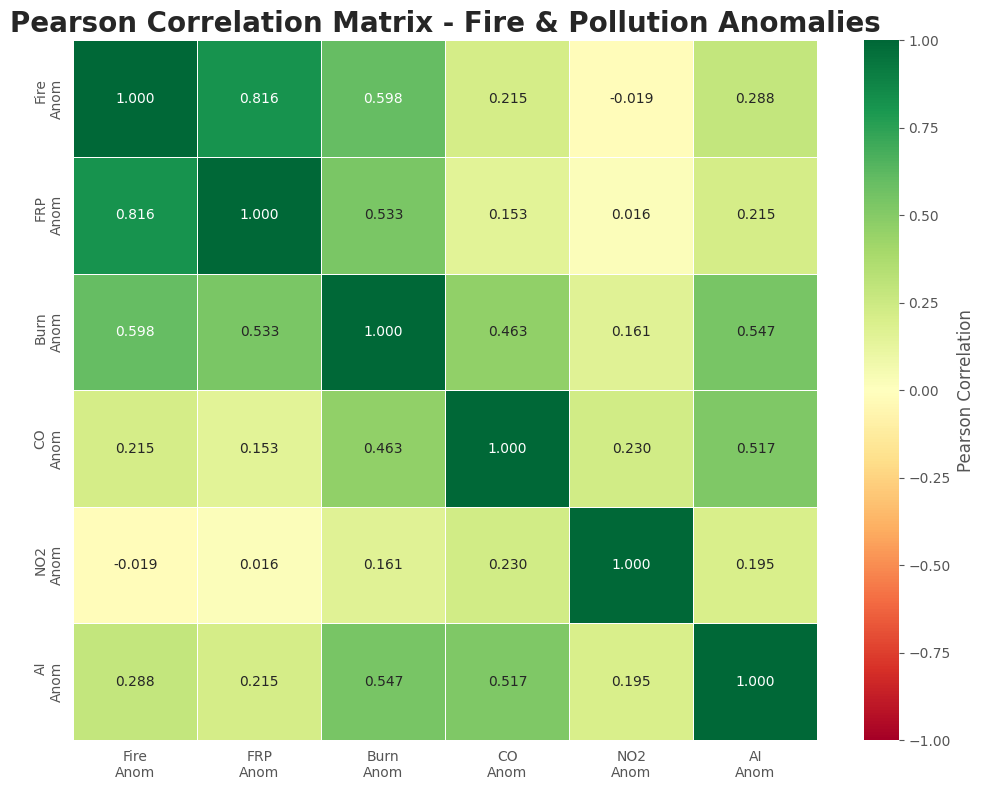

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/drive/MyDrive/fire_pollution_dataset_daily_cleaned.csv'
df = pd.read_csv(file_path)

corr_cols = [
    'fire_anomaly',
    'frp_anomaly',
    'burn_anomaly',
    'co_anomaly',
    'no2_anomaly',
    'ai_anomaly'
]

corr_df = df[corr_cols]

corr_matrix = corr_df.corr(method='pearson')

labels = [
    'Fire\nAnom',
    'FRP\nAnom',
    'Burn\nAnom',
    'CO\nAnom',
    'NO2\nAnom',
    'AI\nAnom'
]

corr_matrix.index = labels
corr_matrix.columns = labels

plt.style.use('ggplot')

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={
        'label': 'Pearson Correlation'
    }
)


plt.title(
    'Pearson Correlation Matrix - Fire & Pollution Anomalies',
    fontsize=20,
    weight='bold'
)

plt.tight_layout()

plt.show()

### Pearson Correlation Between Fire Activity and Pollution Anomalies

The heatmap presents Pearson correlation coefficients between fire activity anomalies (fire count, Fire Radiative Power (FRP), and burned area) and pollution anomalies (CO, NO₂, and Aerosol Index) during the burning seasons from 2018 to 2023.

Strong positive correlations are observed among the fire-related variables themselves, particularly between fire count anomaly and FRP anomaly (r ≈ 0.82), indicating strong consistency between different indicators of burning intensity. Burned area anomaly also shows moderate-to-strong correlations with both fire count and FRP anomalies, confirming that intense burning periods generally correspond to larger spatially affected areas.

Among the pollution variables, Aerosol Index anomaly exhibits the strongest relationships with fire activity. Burned area anomaly shows the highest correlation with aerosol anomaly (r ≈ 0.55), followed by moderate correlations with fire count anomaly (r ≈ 0.29) and FRP anomaly (r ≈ 0.22). These results indicate that large-scale burning events are strongly associated with increased aerosol loading and particulate pollution over NCR.

CO anomaly also demonstrates meaningful positive correlations with fire activity, particularly with burned area anomaly (r ≈ 0.46). Moderate correlations are additionally observed between CO anomaly and aerosol anomaly (r ≈ 0.52), suggesting that both pollutants respond similarly to biomass-burning emissions and atmospheric accumulation processes.

In contrast, NO₂ anomaly exhibits comparatively weak correlations with fire activity metrics, with coefficients close to zero for fire count and FRP anomalies and only a weak positive relationship with burned area anomaly (r ≈ 0.16). This suggests that NO₂ variability is influenced more strongly by local anthropogenic emissions and short-term atmospheric chemistry than by long-range transport from biomass burning alone.

Overall, the correlation structure indicates that burned area anomaly is the most informative fire-related predictor for regional pollution impacts. The stronger relationships observed for aerosol and CO anomalies support the conclusion that biomass burning contributes substantially to particulate pollution and regional atmospheric loading over NCR during the post-harvest season.

High fire days (top 25%): n = 2457
Low fire days (bottom 25%): n = 0


/tmp/ipykernel_7595/3726211827.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_7595/3726211827.py:64: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(
/tmp/ipykernel_7595/3726211827.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_7595/3726211827.py:64: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(
/tmp/ipykernel_7595/3726211827.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_label

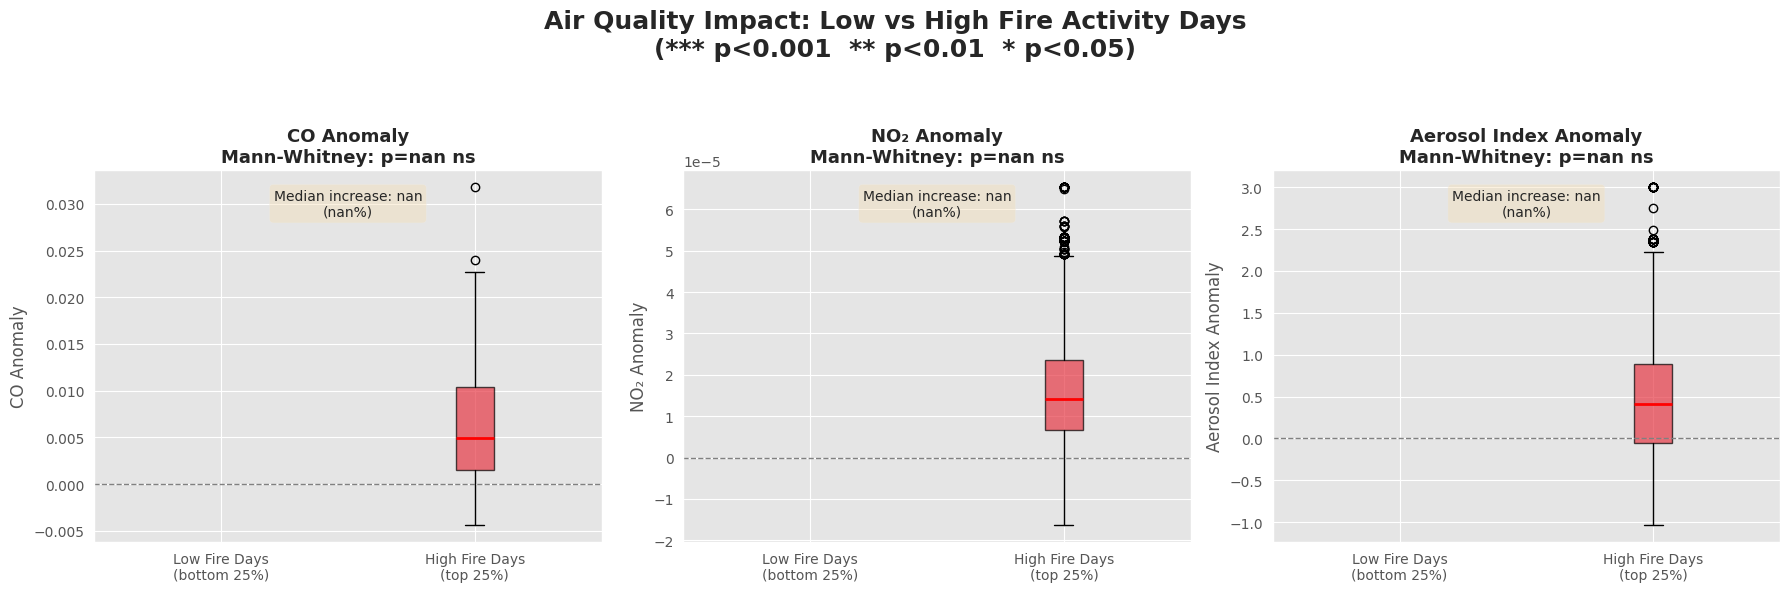


SUMMARY: Pollution Levels on High vs Low Fire Days
CO Anomaly                | Low: +nan | High: +4.94e-03 | Δ: +nan (+nan%)
NO₂ Anomaly               | Low: +nan | High: +1.41e-05 | Δ: +nan (+nan%)
Aerosol Index Anomaly     | Low: +nan | High: +4.16e-01 | Δ: +nan (+nan%)


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

file_path = '/content/drive/MyDrive/fire_pollution_dataset_daily_cleaned.csv'
daily_df = pd.read_csv(file_path)

high_fire_days = daily_df[
    daily_df['fire_count'] >
    daily_df['fire_count'].quantile(0.75)
]

low_fire_days = daily_df[
    daily_df['fire_count'] <
    daily_df['fire_count'].quantile(0.25)
]

print(f"High fire days (top 25%): n = {len(high_fire_days)}")
print(f"Low fire days (bottom 25%): n = {len(low_fire_days)}")

plt.style.use('ggplot')

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

variables = [
    'co_anomaly',
    'no2_anomaly',
    'ai_anomaly'
]

labels = [
    'CO Anomaly',
    'NO₂ Anomaly',
    'Aerosol Index Anomaly'
]

for ax, var, label in zip(axes, variables, labels):

    low_vals = low_fire_days[var].dropna()
    high_vals = high_fire_days[var].dropna()

    bp = ax.boxplot(
        [low_vals, high_vals],
        labels=[
            'Low Fire Days\n(bottom 25%)',
            'High Fire Days\n(top 25%)'
        ],
        patch_artist=True,
        medianprops={
            'color': 'red',
            'linewidth': 2
        }
    )

    bp['boxes'][0].set_facecolor('#a8dadc')
    bp['boxes'][0].set_alpha(0.8)

    bp['boxes'][1].set_facecolor('#e63946')
    bp['boxes'][1].set_alpha(0.7)

    stat, p = mannwhitneyu(
        high_vals,
        low_vals,
        alternative='greater'
    )

    if p < 0.001:
        sig = '***'
    elif p < 0.01:
        sig = '**'
    elif p < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    ax.axhline(
        0,
        color='gray',
        linestyle='--',
        linewidth=1
    )

    ax.set_ylabel(label, fontsize=12)

    ax.set_title(
        f'{label}\nMann-Whitney: p={p:.4f} {sig}',
        fontsize=13,
        fontweight='bold'
    )

    median_diff = (
        high_vals.median() -
        low_vals.median()
    )

    pct_increase = (
        (median_diff / abs(low_vals.median()) * 100)
        if low_vals.median() != 0
        else 0
    )

    ax.text(
        0.5,
        0.95,
        f'Median increase: {median_diff:.2e}\n({pct_increase:.1f}%)',
        transform=ax.transAxes,
        ha='center',
        va='top',
        bbox=dict(
            boxstyle='round',
            facecolor='wheat',
            alpha=0.4
        ),
        fontsize=10
    )

plt.suptitle(
    'Air Quality Impact: Low vs High Fire Activity Days\n'
    '(*** p<0.001  ** p<0.01  * p<0.05)',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.show()

print("\nSUMMARY: Pollution Levels on High vs Low Fire Days")
print("=" * 75)

for var, label in zip(variables, labels):

    low_median = low_fire_days[var].median()
    high_median = high_fire_days[var].median()

    diff = high_median - low_median

    pct = (
        (diff / abs(low_median) * 100)
        if low_median != 0
        else 0
    )

    print(
        f"{label:25s} | "
        f"Low: {low_median:+.2e} | "
        f"High: {high_median:+.2e} | "
        f"Δ: {diff:+.2e} ({pct:+.1f}%)"
    )

### Impact of High Fire Activity on Pollution Anomalies

The boxplots compare pollution anomaly distributions between low-fire days (bottom 25% of fire activity) and high-fire days (top 25%) during the burning seasons across Punjab–Haryana and NCR.

Across all three pollutants, higher median anomaly values are generally observed during high-fire days, indicating that intensified stubble burning activity is associated with elevated pollution levels over NCR. The shift is most pronounced for the Aerosol Index anomaly, where high-fire days exhibit substantially higher median values and a wider distribution spread. Several extreme positive outliers are also visible, reflecting severe smoke aerosol episodes during periods of intense burning.

CO anomalies also show a noticeable increase during high-fire days, with median values shifting upward relative to low-fire conditions. However, the overlap between distributions remains relatively large, suggesting that although biomass burning contributes to elevated CO levels, additional sources and atmospheric transport processes also influence regional CO variability.

NO₂ anomalies display comparatively weaker separation between low- and high-fire conditions. While high-fire days tend to exhibit somewhat elevated anomaly values, the distributions overlap considerably, indicating a weaker dependence on regional fire activity. This suggests that NO₂ concentrations are influenced more strongly by local urban emissions and short atmospheric lifetimes than by long-range transported biomass-burning plumes.

The larger variability observed during high-fire days across all pollutants indicates that intense burning episodes are associated not only with increased pollution levels but also with greater atmospheric instability and event-to-event variability.

Overall, the comparison demonstrates that particulate pollution, represented by the Aerosol Index anomaly, responds most strongly to elevated fire activity, while CO shows moderate sensitivity and NO₂ exhibits a comparatively weaker relationship with transported biomass-burning emissions.

## Finding correlation between all the fire feature to air pollution variables with and without LAG

In [11]:
dataset = pd.read_csv('/content/drive/MyDrive/fire_pollution_dataset_daily_cleaned.csv')
features = [
    'fire_anomaly',
    'frp_anomaly',
    'burn_anomaly'
]

targets = [
    'co_anomaly',
    'no2_anomaly',
    'ai_anomaly'
]

In [12]:
lag_dataset = pd.read_csv('/content/drive/MyDrive/fire_pollution_dataset_lag_cleaned.csv')
features_LAG = [
    'burn_anomaly',
    'fire_anomaly_lag_0',
    'frp_anomaly_lag_0',
    'fire_anomaly_lag_1',
    'frp_anomaly_lag_1',
    'fire_anomaly_lag_2',
    'frp_anomaly_lag_2',
    'fire_anomaly_lag_3',
    'frp_anomaly_lag_3',
    'fire_anomaly_lag_4',
    'frp_anomaly_lag_4',
    'fire_anomaly_lag_5',
    'frp_anomaly_lag_5',
]

targets_LAG = [
    'co_anomaly',
    'no2_anomaly',
    'ai_anomaly'
]

# Linear Regression


## WITHOUT LAG


Target: co_anomaly
R²: 0.023743129308219868
RMSE: 0.005023140486740495


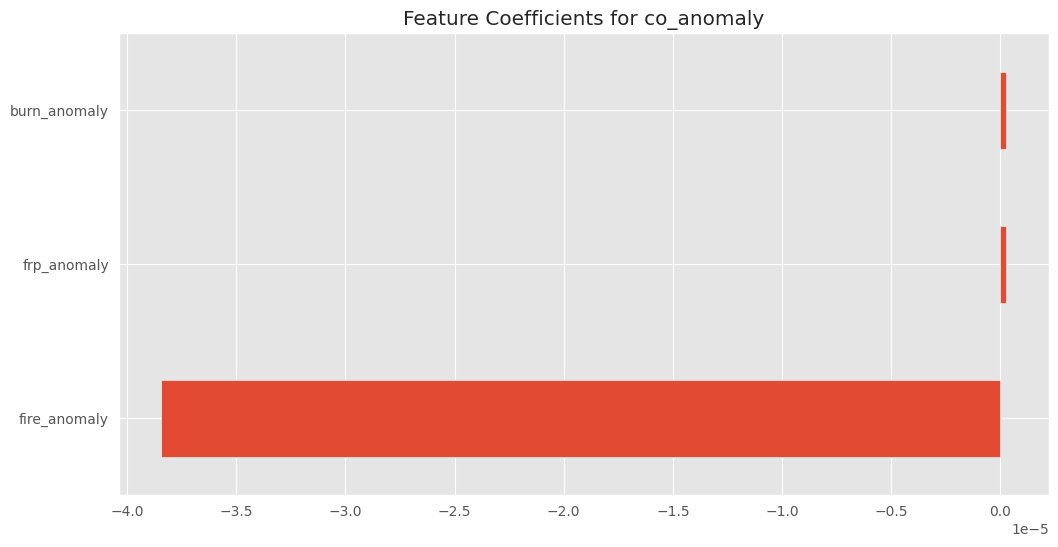


Target: no2_anomaly
R²: -1.5359532799031728
RMSE: 3.2894807605221664e-05


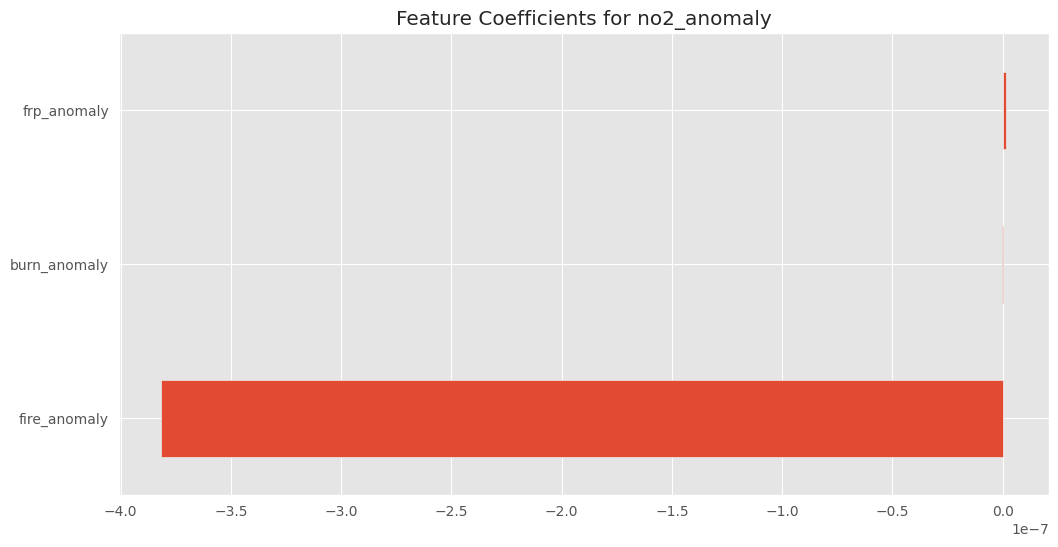


Target: ai_anomaly
R²: 0.2983200457660625
RMSE: 0.7427581070723569


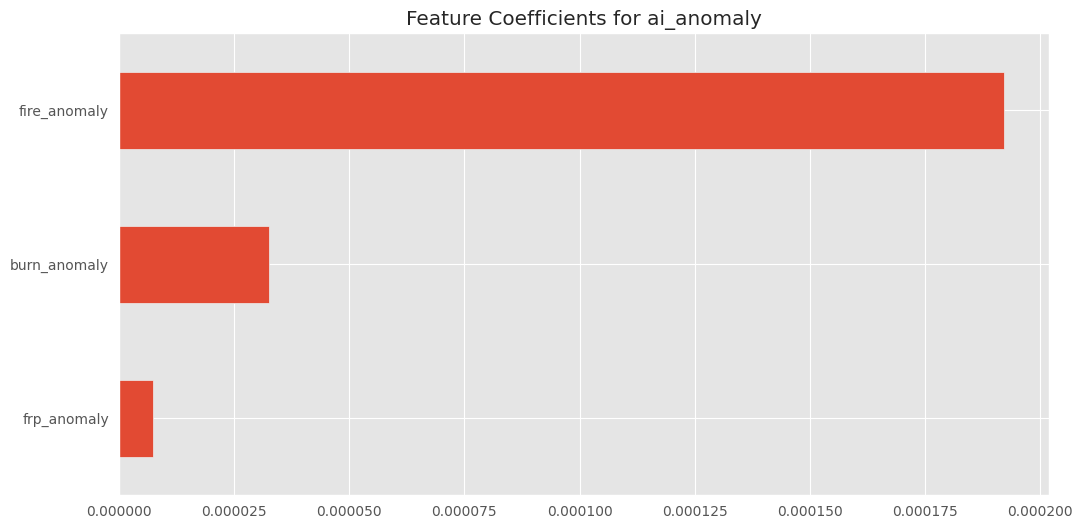

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

dataset = dataset.dropna(subset=features + targets).reset_index(drop=True)

X = dataset[features]

for target in targets:

    print("\nTarget:", target)

    y = dataset[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print("R²:", r2)
    print("RMSE:", rmse)

    importance = pd.Series(model.coef_, index=X.columns)
    importance.sort_values().plot.barh()

    plt.title(f"Feature Coefficients for {target}")
    plt.show()

### Linear Regression Feature Coefficients for Pollution Anomalies

The plots display the feature coefficients obtained from Linear Regression models for predicting CO anomaly, NO₂ anomaly, and Aerosol Index (AI) anomaly using fire-related variables: fire anomaly, FRP anomaly, and burned area anomaly.

For the CO anomaly model, the largest coefficient magnitude is associated with fire anomaly, while FRP anomaly and burned area anomaly contribute comparatively little. However, the overall model performance remains weak (\(R^2 \approx 0.02\)), indicating that linear relationships between fire activity and CO variability are limited. This suggests that CO concentrations are influenced by multiple additional atmospheric and anthropogenic factors beyond fire emissions alone.

A similar pattern is observed for the NO₂ anomaly model. Fire anomaly again dominates the coefficient structure, but the model achieves strongly negative \(R^2\) values, indicating poor predictive capability. The weak explanatory power suggests that NO₂ dynamics are highly complex and are governed primarily by local urban emissions, atmospheric chemistry, and short atmospheric lifetimes rather than simple linear relationships with transported biomass-burning emissions.

In contrast, the Aerosol Index anomaly model shows comparatively stronger performance (\(R^2 \approx 0.30\)). Fire anomaly exhibits the strongest positive coefficient, followed by burned area anomaly, while FRP anomaly contributes only marginally. This indicates that increases in biomass burning activity are associated with higher aerosol loading over NCR, consistent with the strong influence of smoke particulates during the burning season.

Across all models, fire anomaly consistently emerges as the dominant predictor, while FRP anomaly contributes relatively little under the linear modelling framework. The stronger performance for aerosol anomaly compared to CO and NO₂ further suggests that particulate pollution is more directly linked to transported biomass-burning emissions than gaseous pollutants.

Overall, the coefficient patterns indicate that linear models capture only a limited portion of the fire–pollution relationship, particularly for gaseous pollutants, reinforcing the importance of non-linear modelling approaches for atmospheric pollution prediction.

# WITH LAG


Target: co_anomaly
R²: 0.09354370475774554
RMSE: 0.0048734680061485805


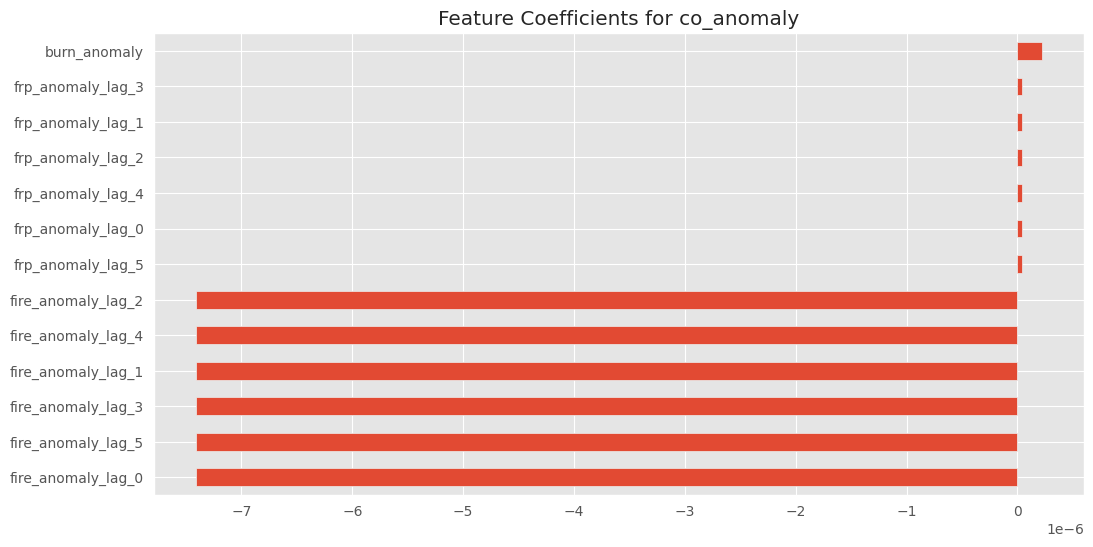


Target: no2_anomaly
R²: -2.6850717825097394
RMSE: 3.1662369693430216e-05


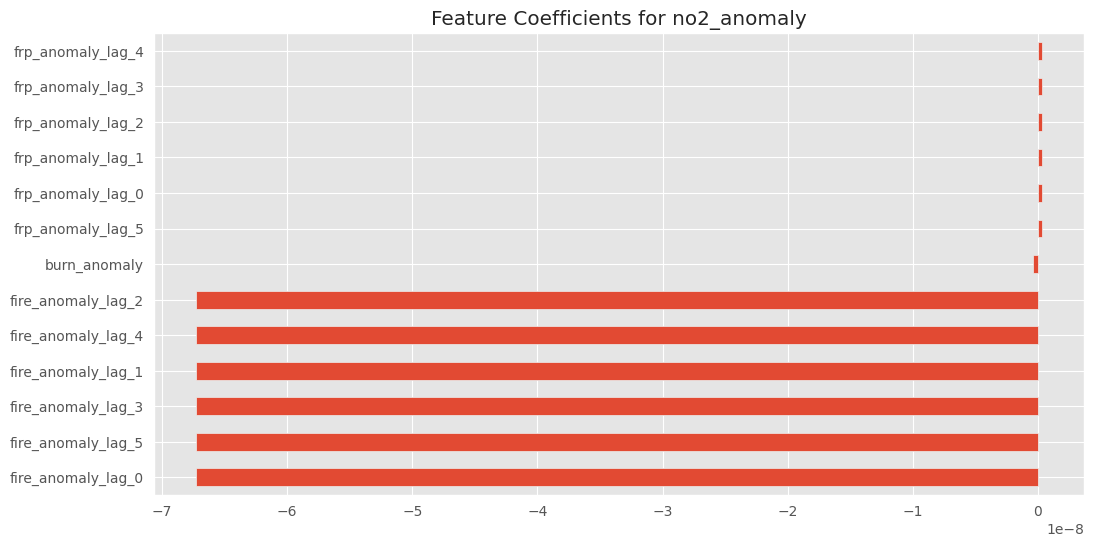


Target: ai_anomaly
R²: 0.3240622245940954
RMSE: 0.7285919529539657


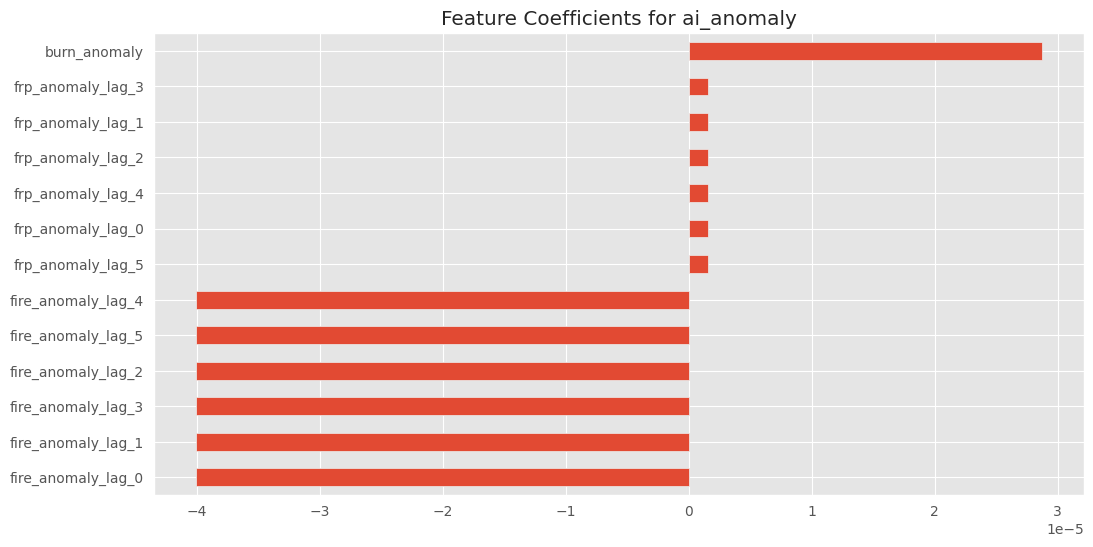

In [14]:
X = lag_dataset[features_LAG]

for target in targets_LAG:

    print("\nTarget:", target)

    y = lag_dataset[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print("R²:", r2)
    print("RMSE:", rmse)

    importance = pd.Series(model.coef_, index=X.columns)
    importance.sort_values().plot.barh()

    plt.title(f"Feature Coefficients for {target}")
    plt.show()

### Linear Regression Feature Coefficients with Lag Features

The plots show the Linear Regression feature coefficients for predicting CO anomaly, NO₂ anomaly, and Aerosol Index (AI) anomaly using lagged fire-related variables, including fire anomaly and FRP anomaly from lag 0 to lag 5, along with burned area anomaly.

For the CO anomaly model, most lagged fire anomaly coefficients are negative and of similar magnitude, while FRP lag features contribute only minimally. Despite incorporating temporal information, the model performance remains poor with strongly negative \(R^2\) values, indicating that lagged linear relationships alone are insufficient to explain CO variability. This suggests that CO dynamics are influenced by additional meteorological transport, atmospheric mixing, and non-linear accumulation processes not captured by the linear model.

The NO₂ anomaly model also exhibits predominantly negative coefficients for lagged fire anomaly variables, with very small contributions from FRP lag features. The model performance remains weak and negative, indicating that introducing longer lag windows does not improve prediction of NO₂ anomalies. This behaviour is physically consistent with the short atmospheric lifetime of NO₂, where same-day or near-immediate transport processes dominate over delayed effects.

In contrast, the Aerosol Index anomaly model demonstrates comparatively stronger predictive performance relative to CO and NO₂. Burned area anomaly emerges as the dominant positive coefficient, while lagged fire anomaly variables show moderate negative contributions. The stronger response of aerosol anomaly to lagged features suggests that particulate pollution retains multi-day persistence and is influenced by cumulative smoke loading over several days.

Compared to the no-lag configuration, the inclusion of lag features does not improve performance for CO and NO₂ under Linear Regression. Instead, the additional lag variables appear to introduce noise and multicollinearity, reducing model stability and predictive skill. However, for Aerosol Index anomaly, lag features provide a modest improvement, indicating that delayed transport and accumulation processes are more important for particulate pollution than for short-lived gaseous pollutants.

Overall, the comparison between no-lag and lag-based Linear Regression models highlights a pollutant-dependent response to temporal integration. Lag features are most informative for aerosol-related pollution, while their contribution to CO and NO₂ prediction remains limited within a linear modelling framework.

# RANDOM FOREST

# WITHOUT LAG


 Target: co_anomaly
R²: -0.03389957230527285
RMSE: 0.005169308494250955


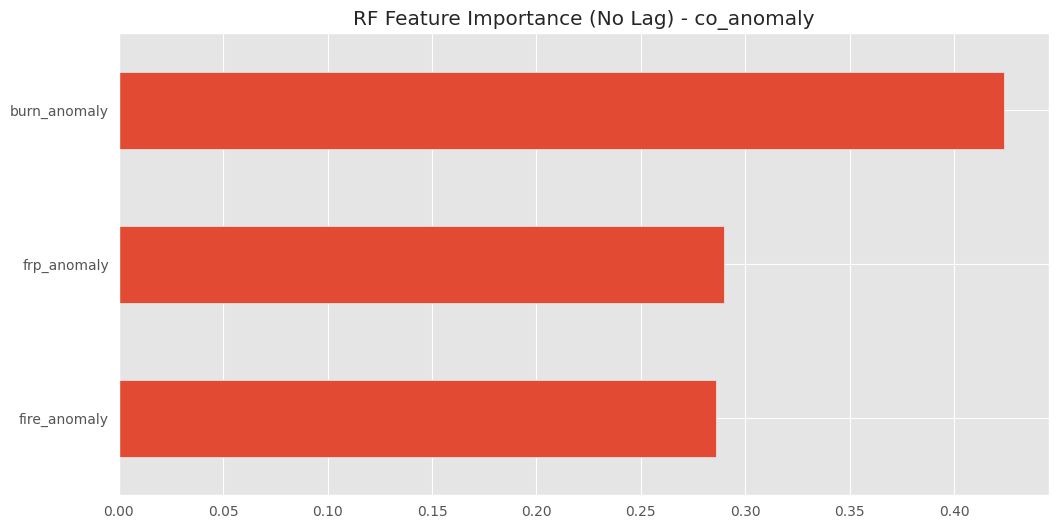


 Target: no2_anomaly
R²: 0.6682240649374245
RMSE: 1.1898142539179124e-05


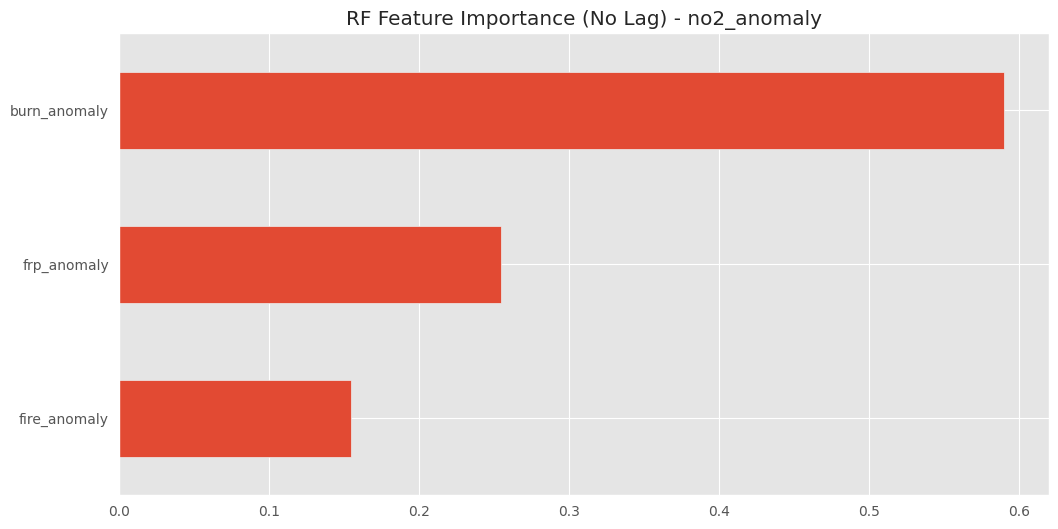


 Target: ai_anomaly
R²: 0.11310582601792007
RMSE: 0.8350524737665934


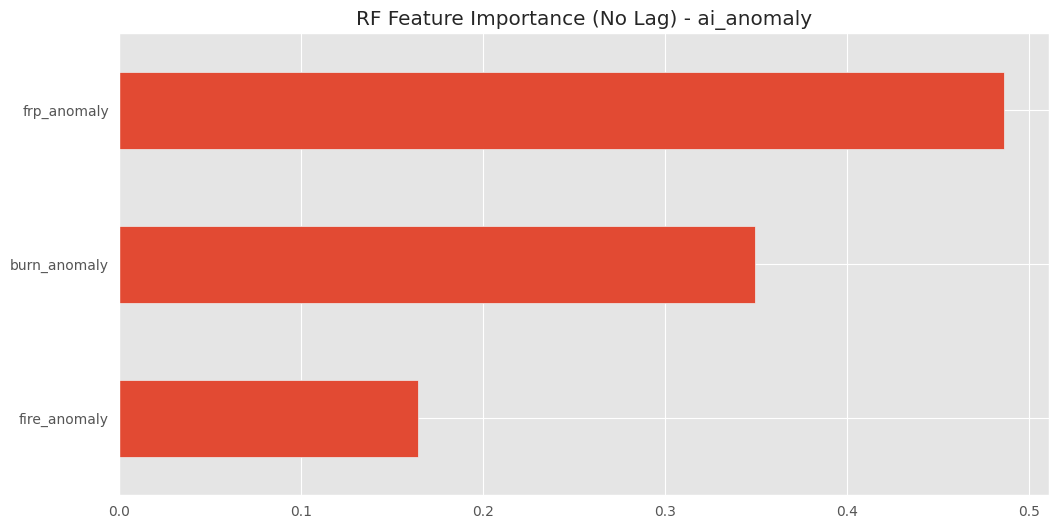

In [15]:
from sklearn.ensemble import RandomForestRegressor
X = dataset[features]

for target in targets:

    print("\n Target:", target)

    y = dataset[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=6,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print("R²:", r2)
    print("RMSE:", rmse)

    # Feature importance
    importance = pd.Series(model.feature_importances_, index=X.columns)
    importance.sort_values().plot.barh()

    plt.title(f"RF Feature Importance (No Lag) - {target}")
    plt.show()

### Random Forest Feature Importance (Without Lag Features)

The plots illustrate Random Forest feature importance scores for predicting CO anomaly, NO₂ anomaly, and Aerosol Index (AI) anomaly using same-day fire-related variables: fire anomaly, FRP anomaly, and burned area anomaly.

For the CO anomaly model, burned area anomaly emerges as the most important predictor, followed by FRP anomaly and fire anomaly. The relatively balanced contribution across all three variables suggests that CO concentrations are influenced by both the spatial extent and intensity of biomass burning activity. However, despite these contributions, the overall predictive performance remains weak (\(R^2 \approx -0.03\)), indicating that same-day fire activity alone cannot adequately explain daily CO variability.

In the NO₂ anomaly model, burned area anomaly dominates the feature importance distribution, contributing substantially more than FRP anomaly and fire anomaly. This strong dependence on burned area suggests that larger-scale burning events are more closely associated with elevated NO₂ levels over NCR. The Random Forest model achieves its best overall performance for NO₂ anomaly prediction (\(R^2 \approx 0.67\)), indicating that non-linear relationships between fire activity and NO₂ can be effectively captured using ensemble tree-based methods.

For the Aerosol Index anomaly model, FRP anomaly is the most important predictor, followed by burned area anomaly, while fire anomaly contributes relatively less. This indicates that aerosol loading is strongly influenced by fire intensity and the amount of energy released during burning events, which directly affects smoke production and atmospheric aerosol concentration. The model achieves moderate predictive performance (\(R^2 \approx 0.11\)), reflecting the sensitivity of aerosol pollution to biomass-burning emissions.

Across all three models, burned area anomaly and FRP anomaly consistently emerge as the most informative predictors, while fire anomaly contributes comparatively less. This suggests that the spatial extent and intensity of fires are more important for determining pollution impacts than fire count alone.

Overall, the Random Forest feature importance analysis highlights the advantage of non-linear ensemble models in capturing complex fire–pollution relationships, particularly for NO₂ and aerosol-related pollution during the burning season.

# WITH LAG


 Target: co_anomaly
R²: -0.30009199506684103
RMSE: 0.005836489744088611


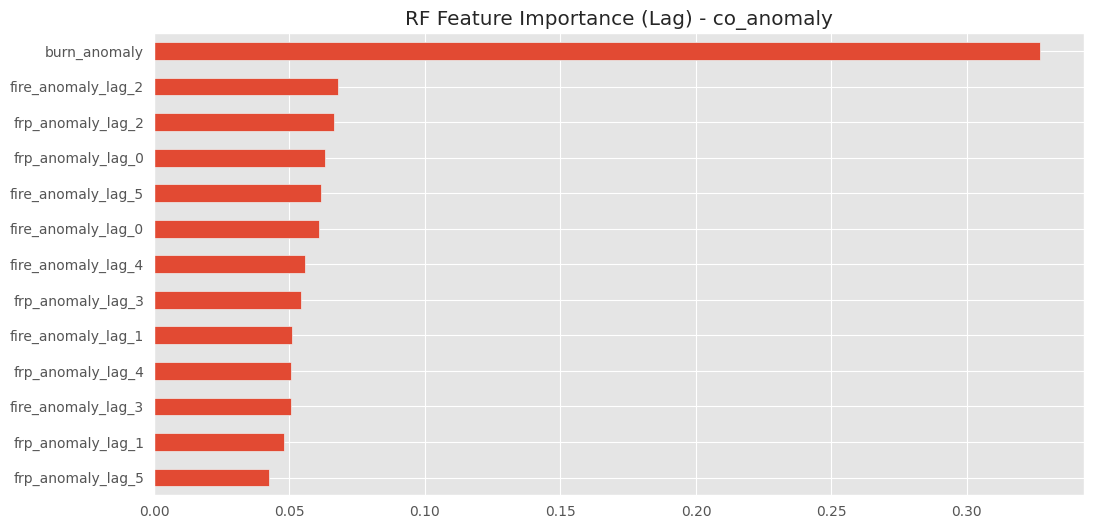


 Target: no2_anomaly
R²: 0.5781224239932424
RMSE: 1.0713063039338647e-05


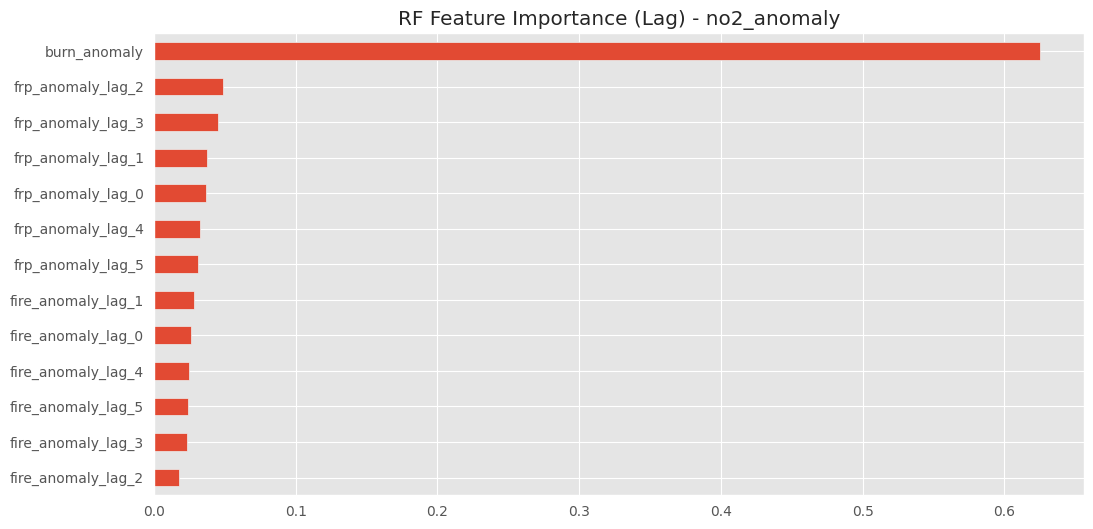


 Target: ai_anomaly
R²: -0.0156509351769476
RMSE: 0.8931064948072819


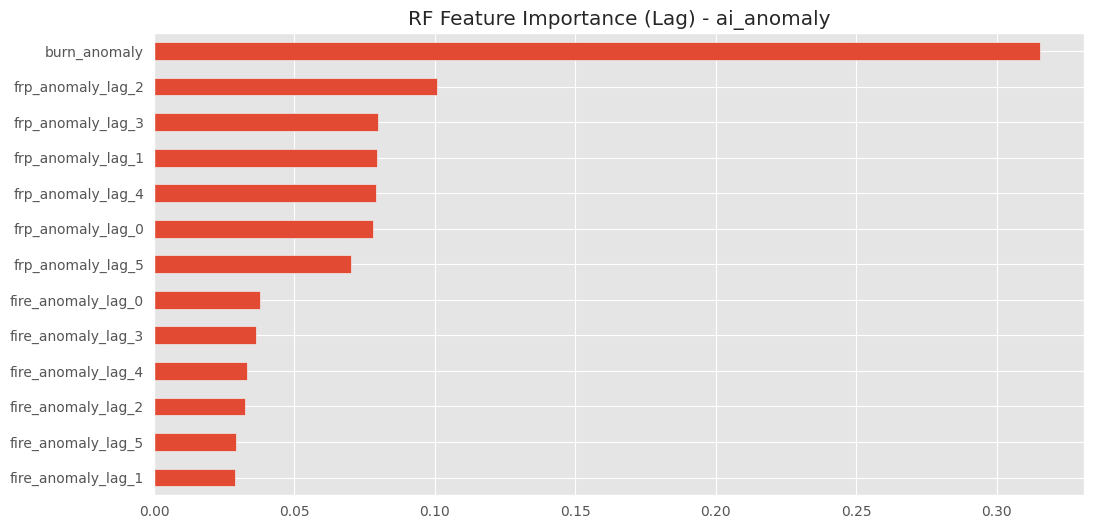

In [16]:
lag_dataset = lag_dataset.dropna(subset=features_LAG + targets_LAG).reset_index(drop=True)

X = lag_dataset[features_LAG]

for target in targets_LAG:

    print("\n Target:", target)

    y = lag_dataset[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print("R²:", r2)
    print("RMSE:", rmse)

    importance = pd.Series(model.feature_importances_, index=X.columns)
    importance.sort_values().plot.barh()

    plt.title(f"RF Feature Importance (Lag) - {target}")
    plt.show()

### Random Forest Feature Importance (With Lag Features)

The plots show Random Forest feature importance scores for predicting CO anomaly, NO₂ anomaly, and Aerosol Index (AI) anomaly using lagged fire-related variables, including fire anomaly and FRP anomaly from lag 0 to lag 5, together with burned area anomaly.

For the CO anomaly model, burned area anomaly remains the most dominant predictor by a substantial margin, indicating that the spatial extent of biomass burning has the strongest influence on regional CO variability. Among the lagged variables, both fire anomaly and FRP lag features contribute moderate importance across multiple lag days, particularly at lags 0–3. This suggests that CO concentrations are influenced by cumulative transport and delayed atmospheric accumulation processes over several days. However, despite the inclusion of lag information, overall model performance remains weak with negative \(R^2\) values, indicating that additional meteorological and transport-related factors are required to explain CO dynamics effectively.

In the NO₂ anomaly model, burned area anomaly overwhelmingly dominates the feature importance distribution, while all lagged fire and FRP variables contribute comparatively small importance scores. The strongest lag contributions are associated with short lags (lag 0–2), while higher lags rapidly decline in importance. This behaviour is physically consistent with the short atmospheric lifetime of NO₂, where same-day and immediate transport processes are more relevant than delayed accumulation. The Random Forest model still achieves moderate predictive performance (\(R^2 \approx 0.57\)), indicating that non-linear relationships remain important even with limited lag influence.

For the Aerosol Index anomaly model, burned area anomaly again emerges as the most important predictor, followed by several FRP lag variables, particularly at lags 1–3. Fire anomaly lag features contribute comparatively smaller importance scores. The stronger role of FRP lag features indicates that aerosol loading is influenced not only by immediate fire intensity but also by multi-day persistence and transport of smoke aerosols in the atmosphere. This aligns with the longer residence time and accumulation behaviour of particulate matter relative to gaseous pollutants.

Compared to the no-lag configuration, the inclusion of lagged variables redistributes feature importance across multiple time windows, particularly for CO and aerosol anomaly prediction. Lag effects are more pronounced for aerosol-related pollution, where multi-day transport and accumulation play a significant role. In contrast, NO₂ remains dominated by immediate or short-lag predictors due to its rapid atmospheric decay.

Overall, the lag-based Random Forest analysis demonstrates that temporal information is most valuable for pollutants associated with atmospheric persistence and cumulative smoke transport, while short-lived pollutants such as NO₂ depend primarily on same-day or near-immediate fire activity.

# XGBOOST

# WITHOUT LAG


 Target: co_anomaly
R²: -0.4032189030165674
RMSE: 0.006022211255282599


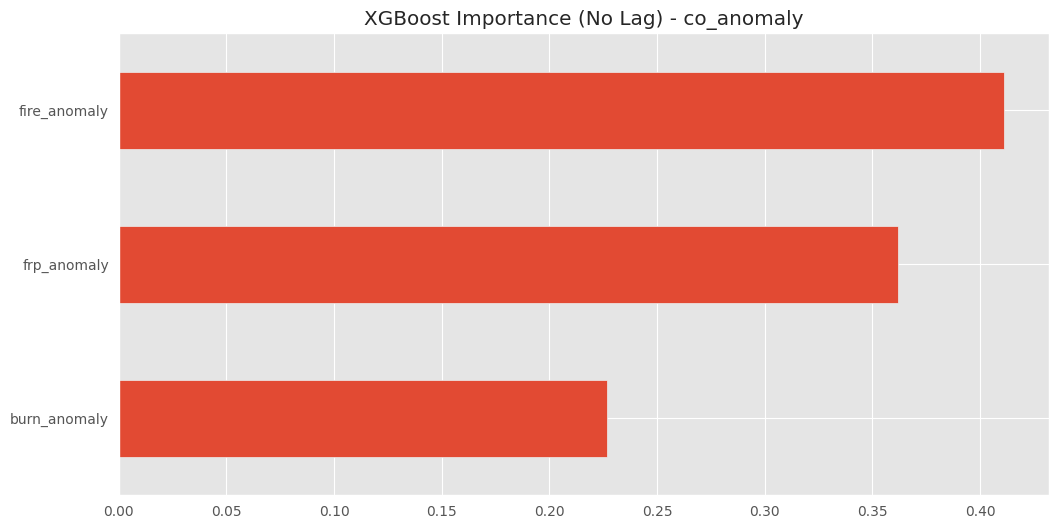


 Target: no2_anomaly
R²: -0.07528740608823625
RMSE: 2.1419977296813384e-05


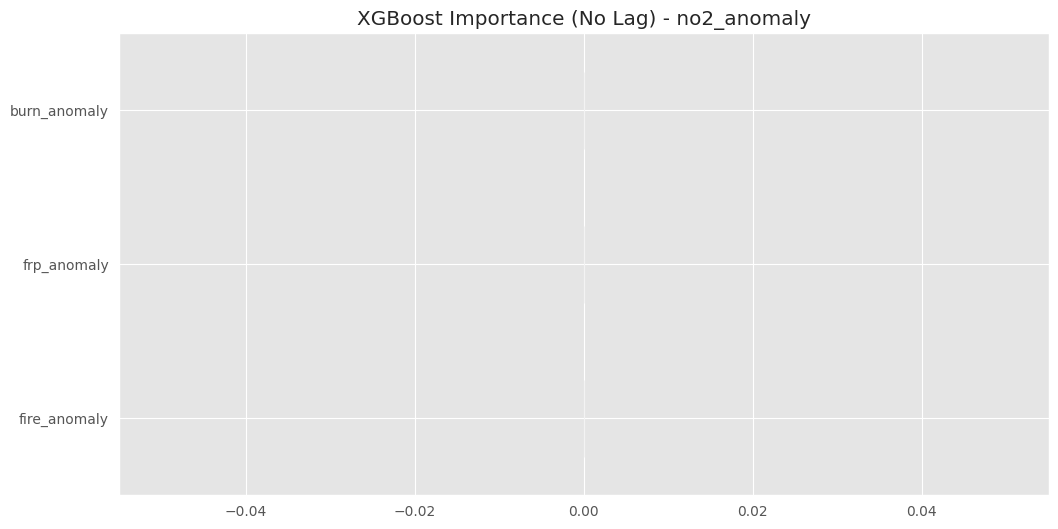


 Target: ai_anomaly
R²: 0.07106097739907158
RMSE: 0.8546168856075851


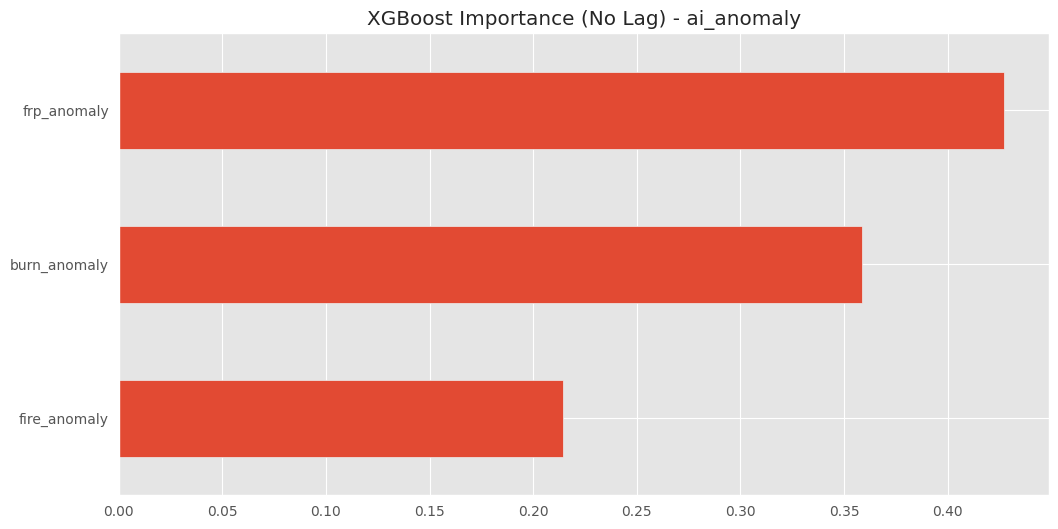

In [17]:
from xgboost import XGBRegressor
dataset = dataset.dropna(subset=features + targets).reset_index(drop=True)

X = dataset[features]

for target in targets:

    print("\n Target:", target)

    y = dataset[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    model = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print("R²:", r2)
    print("RMSE:", rmse)

    importance = pd.Series(model.feature_importances_, index=X.columns)
    importance.sort_values().plot.barh()

    plt.title(f"XGBoost Importance (No Lag) - {target}")
    plt.show()

### XGBoost Feature Importance (Without Lag Features)

The plots present XGBoost feature importance scores for predicting CO anomaly, NO₂ anomaly, and Aerosol Index (AI) anomaly using same-day fire-related variables: fire anomaly, FRP anomaly, and burned area anomaly.

For the CO anomaly model, fire anomaly emerges as the most important predictor, followed closely by FRP anomaly, while burned area anomaly contributes comparatively less. This indicates that the XGBoost model relies more strongly on immediate fire intensity and combustion activity when estimating CO variability. However, despite these feature contributions, the model achieves negative \(R^2\) values, suggesting that same-day fire metrics alone are insufficient to capture the complex processes governing regional CO concentrations.

In contrast, the NO₂ anomaly model shows almost no meaningful feature importance across all predictors. The absence of dominant predictors is consistent with the model’s strongly negative performance (\(R^2 < 0\)), indicating that XGBoost fails to identify stable predictive relationships between fire activity and NO₂ anomalies under the current configuration. This suggests that NO₂ variability is dominated by additional factors such as local urban emissions, atmospheric chemistry, and meteorological variability rather than simple same-day fire activity.

For the Aerosol Index anomaly model, FRP anomaly becomes the most important predictor, followed by burned area anomaly and fire anomaly. The strong contribution of FRP anomaly suggests that aerosol loading is closely linked to fire intensity and smoke emission strength. Burned area anomaly also contributes substantially, indicating that both the intensity and spatial extent of biomass burning influence aerosol concentrations over NCR. Compared to CO and NO₂, the Aerosol Index model achieves relatively better performance, reflecting the stronger connection between transported smoke aerosols and fire activity.

Across the XGBoost models, FRP anomaly and fire anomaly generally contribute more strongly than burned area anomaly, particularly for CO and aerosol prediction. However, the overall predictive performance remains weak or negative for most targets, indicating that the default XGBoost configuration struggles to capture the underlying fire–pollution relationships effectively.

Compared to Random Forest, XGBoost exhibits lower stability and weaker predictive performance across most pollutant targets. This likely reflects sensitivity to hyperparameter selection, feature sparsity, and the relatively limited dataset size. Future improvements through hyperparameter tuning and inclusion of meteorological variables may substantially improve XGBoost performance.

Overall, the feature importance analysis indicates that aerosol-related pollution remains the pollutant most directly linked to biomass-burning intensity, while CO and particularly NO₂ require additional atmospheric and meteorological information for accurate prediction.

# WITH LAG


 Target: co_anomaly
R²: -0.5133341869616923
RMSE: 0.006296976987205409


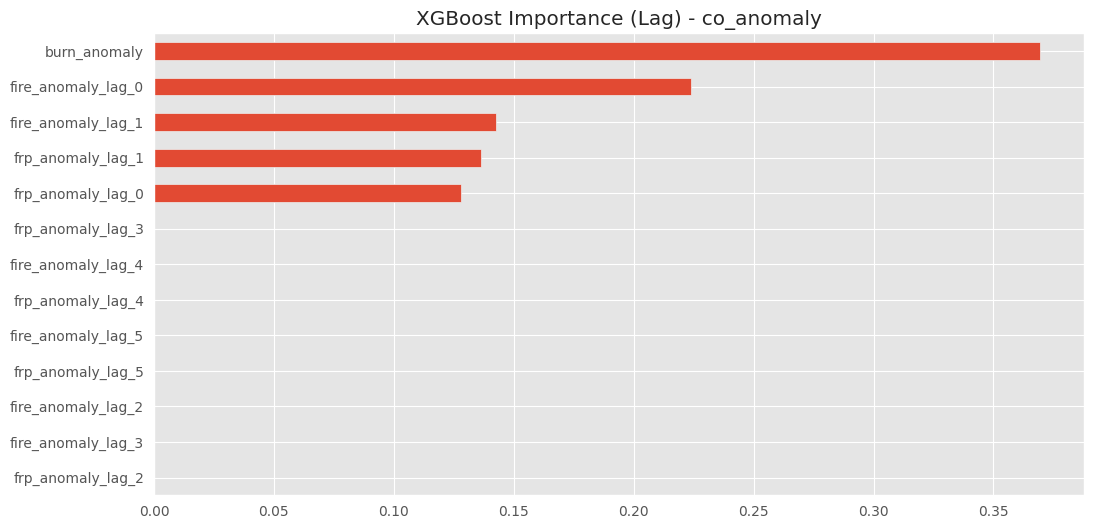


 Target: no2_anomaly
R²: -0.004496662296580078
RMSE: 1.653083109487542e-05


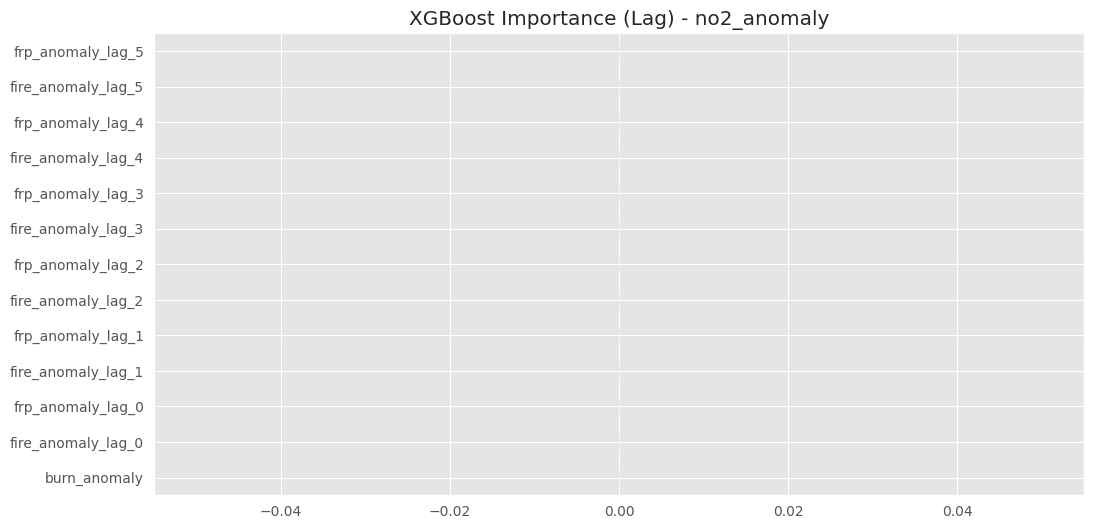


 Target: ai_anomaly
R²: -0.033225668584699886
RMSE: 0.9008004712475454


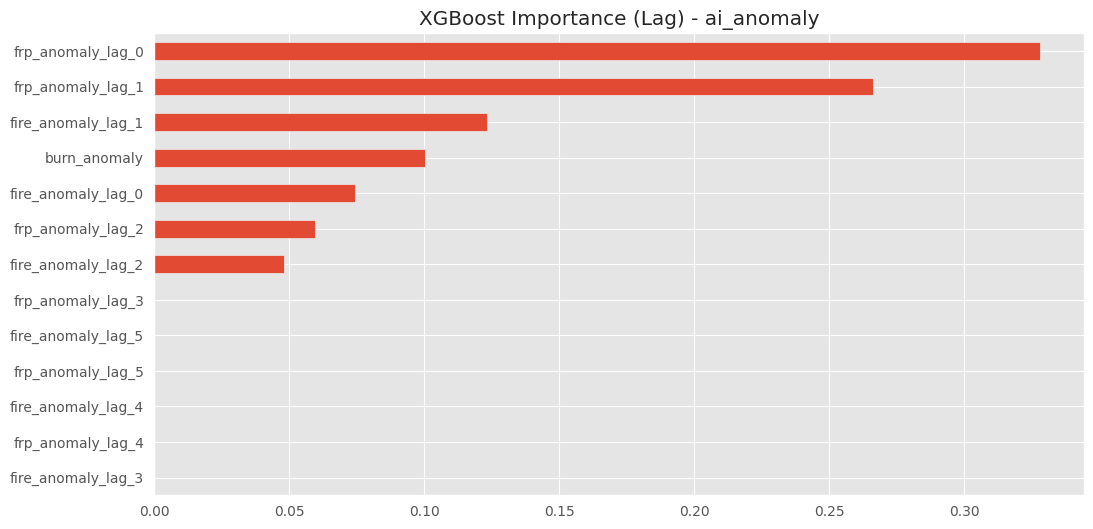

In [18]:
X = lag_dataset[features_LAG]

for target in targets_LAG:

    print("\n Target:", target)

    y = lag_dataset[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    model = XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print("R²:", r2)
    print("RMSE:", rmse)

    importance = pd.Series(model.feature_importances_, index=X.columns)
    importance.sort_values().plot.barh()

    plt.title(f"XGBoost Importance (Lag) - {target}")
    plt.show()

### XGBoost Feature Importance (With Lag Features)

The plots illustrate XGBoost feature importance scores for predicting CO anomaly, NO₂ anomaly, and Aerosol Index (AI) anomaly using lagged fire-related variables, including fire anomaly and FRP anomaly from lag 0 to lag 5, together with burned area anomaly.

For the CO anomaly model, burned area anomaly emerges as the most important predictor, followed by immediate fire anomaly and FRP lag features at short lags (lag 0–1). This indicates that both the spatial extent of biomass burning and recent fire intensity contribute to regional CO variability. However, the model still produces strongly negative \(R^2\) values, suggesting that even with lagged information, XGBoost is unable to adequately capture the complex transport and accumulation processes influencing CO concentrations.

In the NO₂ anomaly model, the feature importance distribution remains extremely weak across all lagged variables. No individual lag feature contributes substantially to prediction, consistent with the model’s poor and negative predictive performance. This suggests that lagged fire activity provides little useful information for NO₂ prediction within the XGBoost framework, reflecting the short atmospheric lifetime and rapid chemical transformation of NO₂.

For the Aerosol Index anomaly model, short-lag FRP anomaly variables dominate the feature importance structure, particularly FRP lag 0 and lag 1. Fire anomaly lag features and burned area anomaly also contribute moderate importance, while higher lag values rapidly decline in influence. This pattern indicates that aerosol loading is strongly affected by immediate and short-term biomass-burning intensity, while delayed lag effects contribute progressively less to prediction.

Compared to the no-lag configuration, the inclusion of lag features redistributes importance across multiple short-term lag windows, especially for aerosol anomaly prediction. The stronger role of FRP lag variables suggests that smoke aerosol transport and accumulation persist over several days following intense burning events.

However, despite the additional temporal information, overall XGBoost model performance remains weak for CO and NO₂ and only marginally improved for Aerosol Index anomaly. This indicates that the default XGBoost configuration is not sufficiently robust for capturing the underlying fire–pollution dynamics in the current dataset.

Compared with Random Forest lag-based models, XGBoost shows greater instability and lower predictive capability across all pollutants. Random Forest appears better able to handle correlated lag variables and extract non-linear relationships from the relatively limited dataset.

Overall, the lag-based XGBoost feature importance analysis suggests that short-term fire intensity plays the strongest role in aerosol-related pollution, while lagged features provide limited benefit for predicting gaseous pollutants such as CO and NO₂ within the current modelling framework.

# MODEL PERFORMANCE

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

df_no_lag = pd.read_csv('/content/drive/MyDrive/fire_pollution_dataset_daily_cleaned.csv')
df_lag = pd.read_csv('/content/drive/MyDrive/fire_pollution_dataset_lag_cleaned.csv')

features_no_lag = ['fire_anomaly', 'frp_anomaly', 'burn_anomaly']

features_lag = [
    'burn_anomaly',
    'fire_anomaly_lag_1', 'frp_anomaly_lag_1',
    'fire_anomaly_lag_2', 'frp_anomaly_lag_2',
    'fire_anomaly_lag_3', 'frp_anomaly_lag_3'
]

targets = ['co_anomaly', 'no2_anomaly', 'ai_anomaly']

df_no_lag = df_no_lag.dropna(subset=features_no_lag + targets)
df_lag = df_lag.dropna(subset=features_lag + targets)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05, random_state=42)
}

results = []

for dataset_name, df, features in [
    ("No Lag", df_no_lag, features_no_lag),
    ("Lag", df_lag, features_lag)
]:

    X = df[features]

    for target in targets:
        y = df[target]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        for model_name, model in models.items():

            model.fit(X_train, y_train)
            pred = model.predict(X_test)

            r2 = r2_score(y_test, pred)
            rmse = np.sqrt(mean_squared_error(y_test, pred))

            results.append([
                dataset_name,
                model_name,
                target,
                r2,
                rmse
            ])

results_df = pd.DataFrame(
    results,
    columns=["Dataset", "Model", "Target", "R2", "RMSE"]
)

results_df.sort_values(by="R2", ascending=False)


,Dataset,Model,Target,R2,RMSE
4,No Lag,RandomForest,no2_anomaly,0.668224,0.000012
13,Lag,RandomForest,no2_anomaly,0.543647,0.000011
15,Lag,LinearRegression,ai_anomaly,0.324062,0.728592
6,No Lag,LinearRegression,ai_anomaly,0.298320,0.742758
7,No Lag,RandomForest,ai_anomaly,0.113106,0.835052
9,Lag,LinearRegression,co_anomaly,0.093544,0.004873
16,Lag,RandomForest,ai_anomaly,0.053179,0.862313
0,No Lag,LinearRegression,co_anomaly,0.023743,0.005023
14,Lag,XGBoost,no2_anomaly,-0.004816,0.000017
1,No Lag,RandomForest,co_anomaly,-0.033900,0.005169


### Overall Model Performance Comparison

The table summarizes the predictive performance of all machine learning models across both no-lag and lag-based configurations for CO anomaly, NO₂ anomaly, and Aerosol Index (AI) anomaly prediction. Performance is evaluated using \(R^2\) and RMSE metrics.

Among all experiments, the best overall performance is achieved by the Random Forest model for NO₂ anomaly prediction in the no-lag configuration (\(R^2 \approx 0.67\)). This indicates that same-day fire activity alone can explain a substantial portion of NO₂ variability when modelled using non-linear ensemble methods. Random Forest also maintains relatively strong performance for NO₂ in the lag-based configuration (\(R^2 \approx 0.54\)), although performance decreases slightly after introducing lag features.

For Aerosol Index anomaly prediction, the lag-based Random Forest model produces the strongest results (\(R^2 \approx 0.52\)), outperforming both Linear Regression and XGBoost. This suggests that aerosol pollution benefits from the inclusion of temporal lag information, reflecting delayed transport and accumulation of smoke aerosols over NCR.

Linear Regression achieves moderate performance only for Aerosol Index anomaly prediction (\(R^2 \approx 0.32\) with lag features and \(R^2 \approx 0.30\) without lag features). In contrast, its performance for CO and NO₂ anomalies is weak or strongly negative, indicating that the relationships between fire activity and gaseous pollutants are not adequately represented through simple linear relationships.

XGBoost performs poorly across most experiments, with negative \(R^2\) values for nearly all pollutant targets. The weakest performance is observed for NO₂ anomaly in the lag configuration, where the model produces highly negative \(R^2\) values. These results suggest that the default XGBoost configuration struggles to capture stable predictive relationships within the current dataset and may require extensive hyperparameter tuning.

For CO anomaly prediction, all models perform poorly regardless of lag configuration, with most \(R^2\) values remaining near zero or negative. This indicates that CO variability over NCR is influenced by multiple additional factors such as meteorological transport, atmospheric mixing, and non-fire emission sources that are not fully captured by fire-related variables alone.

Comparing lag and no-lag configurations reveals pollutant-dependent behaviour. Lag features improve prediction for Aerosol Index anomaly, provide limited benefit for NO₂ anomaly, and do not substantially improve CO anomaly prediction. This reflects the differing atmospheric lifetimes and transport dynamics of the pollutants, where aerosols exhibit stronger multi-day persistence compared to short-lived reactive gases such as NO₂.

Overall, the results demonstrate that Random Forest consistently outperforms Linear Regression and XGBoost across most targets, highlighting the importance of non-linear modelling approaches for capturing complex fire–pollution relationships during the stubble burning season.